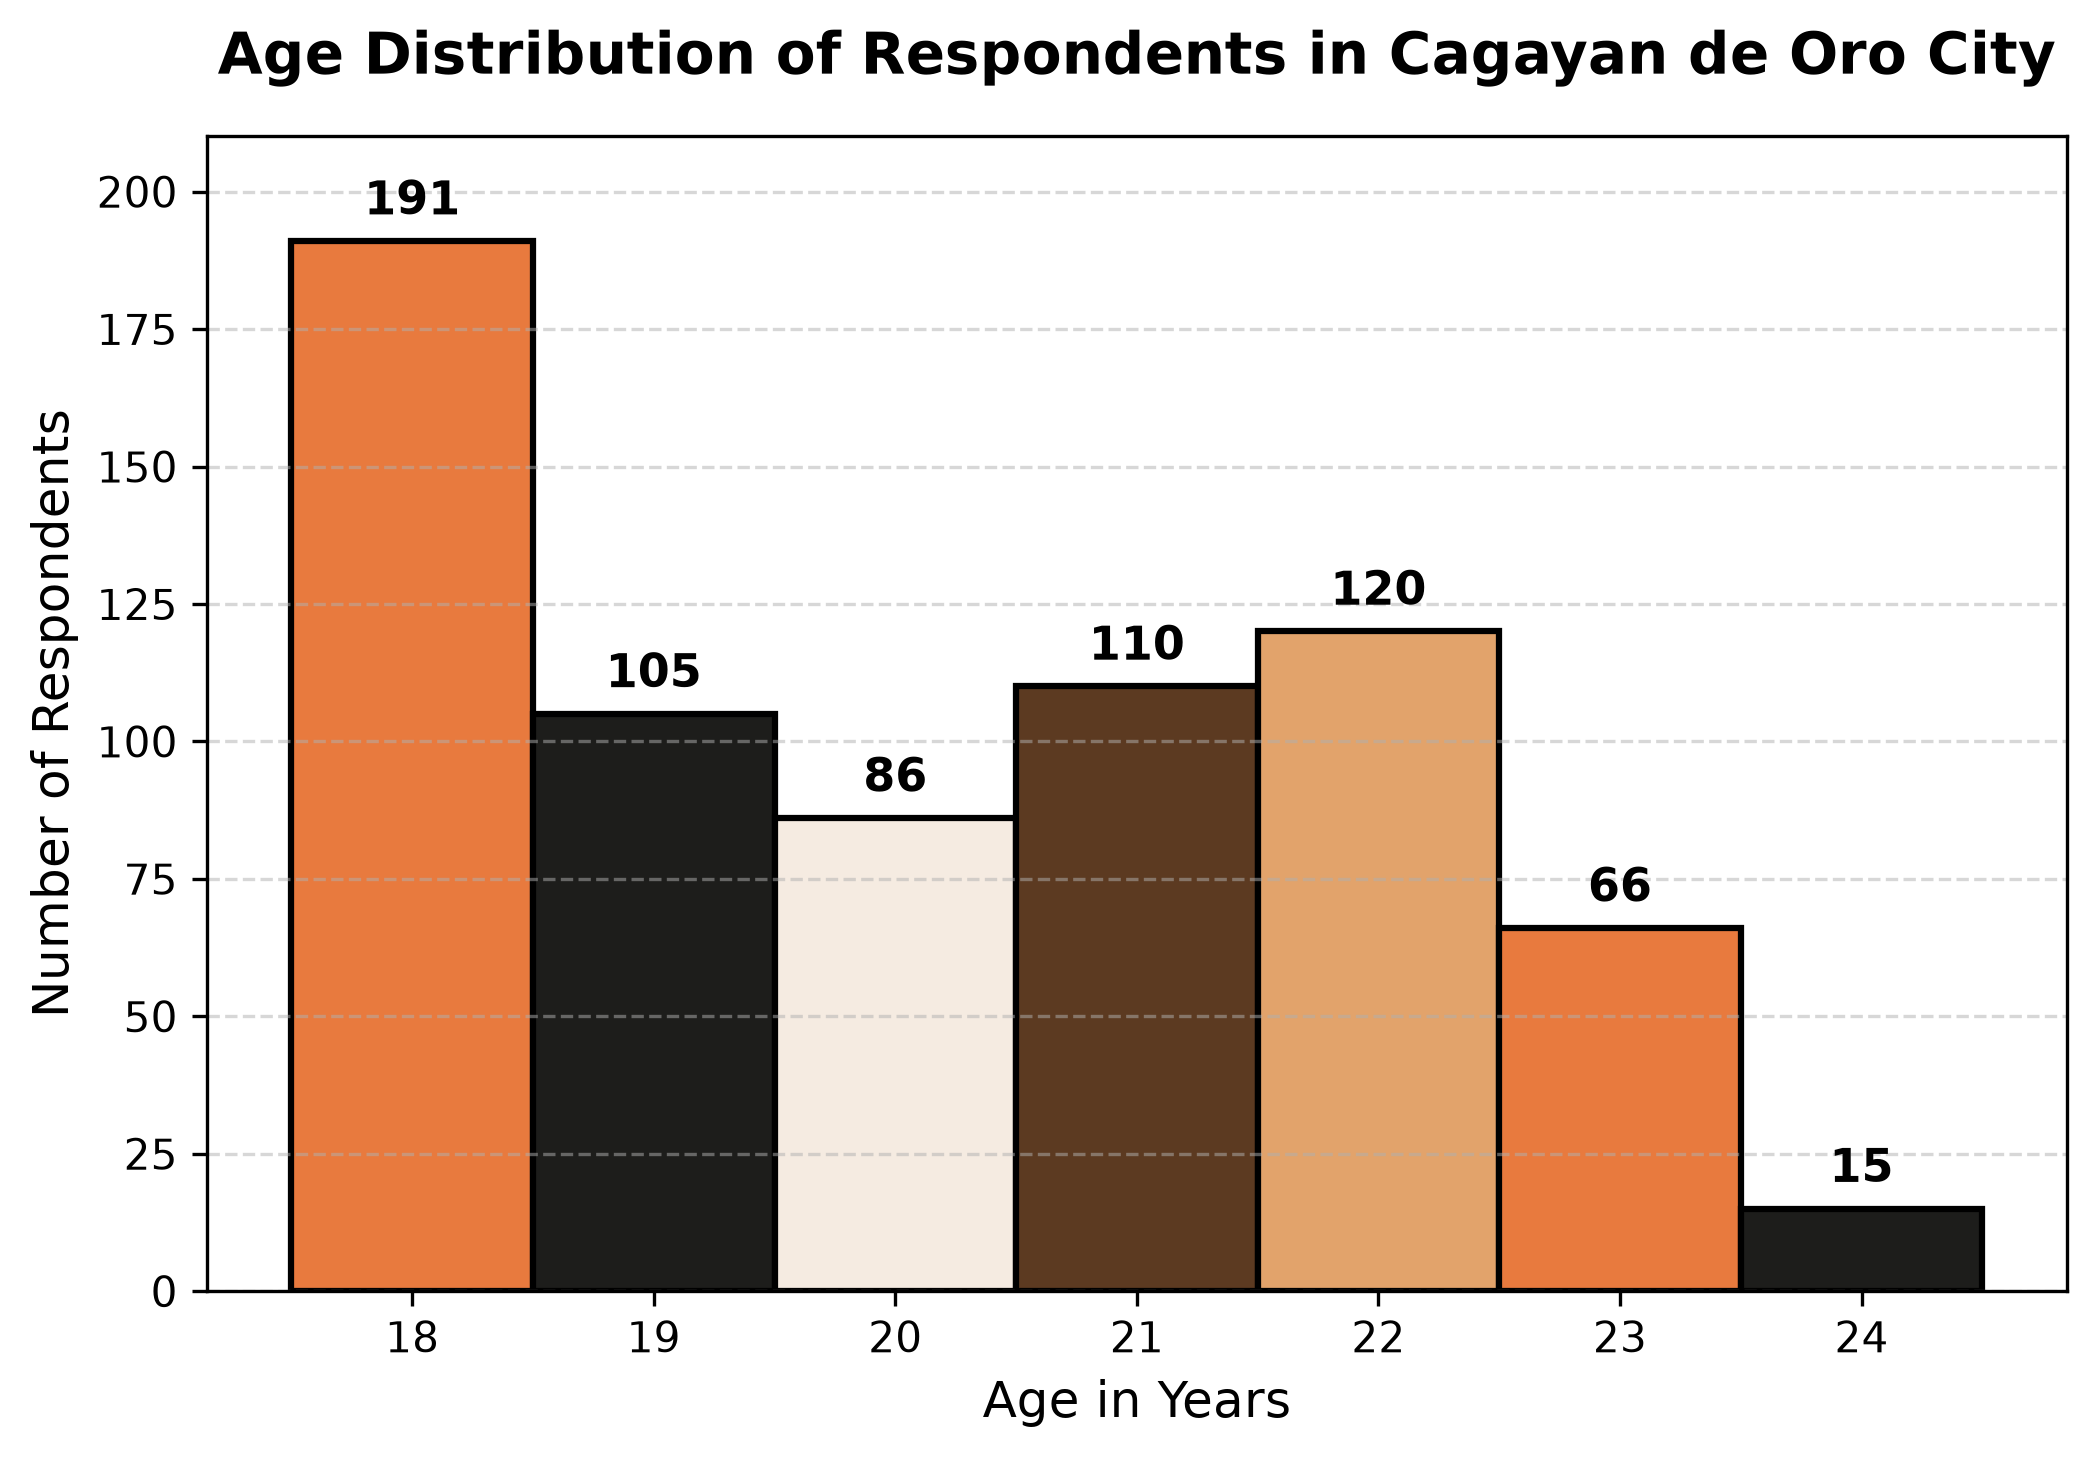

Success! The Calico chart with numbers has been saved to: data_visualization\Age_Distribution.png


In [6]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Load the cleaned data
cleaned_df = pd.read_csv("rawdata/Cleaned_Data.csv")
ages = cleaned_df['Age'].dropna()

# 2. Set up the high-resolution figure
plt.figure(figsize=(8, 5), dpi=300)

calico_colors = ['#E87A3E', '#1D1D1B', '#F5EBE1', '#5C3A21', '#E2A36B']

min_age = int(ages.min())
max_age = int(ages.max())
exact_bins = np.arange(min_age, max_age + 2) - 0.5

# 3. Create the histogram
n, bins, patches = plt.hist(ages, bins=exact_bins, edgecolor='black', linewidth=1.5)

# --- NEW: Give the chart 10% more breathing room at the top so text isn't cut off ---
plt.ylim(0, max(n) * 1.1)

# 4. Loop through each bar to color it AND add the text
for i, patch in enumerate(patches):
    # Set the Calico color
    patch.set_facecolor(calico_colors[i % len(calico_colors)])

    # Get the height of the bar (which is the actual count of people)
    count = int(patch.get_height())

    # Only add text if the bar actually has people in it
    if count > 0:
        # Find the center-top point of the bar
        x_center = patch.get_x() + patch.get_width() / 2

        # --- NEW: Add the text number ---
        # (max(n) * 0.015) pushes the text slightly above the bar so it's readable
        plt.text(
            x_center,
            count + (max(n) * 0.015),
            str(count),
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='bold',
            color='black',
        )

plt.xticks(range(min_age, max_age + 1))
plt.title("Age Distribution of Respondents in Cagayan de Oro City", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Age in Years", fontsize=12)
plt.ylabel("Number of Respondents", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 5. Save to the specific folder
save_folder = "data_visualization"
os.makedirs(save_folder, exist_ok=True)

file_path = os.path.join(save_folder, "Age_Distribution.png")
plt.savefig(file_path, dpi=300, bbox_inches='tight')

plt.show()

print(f"Success! The Calico chart with numbers has been saved to: {file_path}")

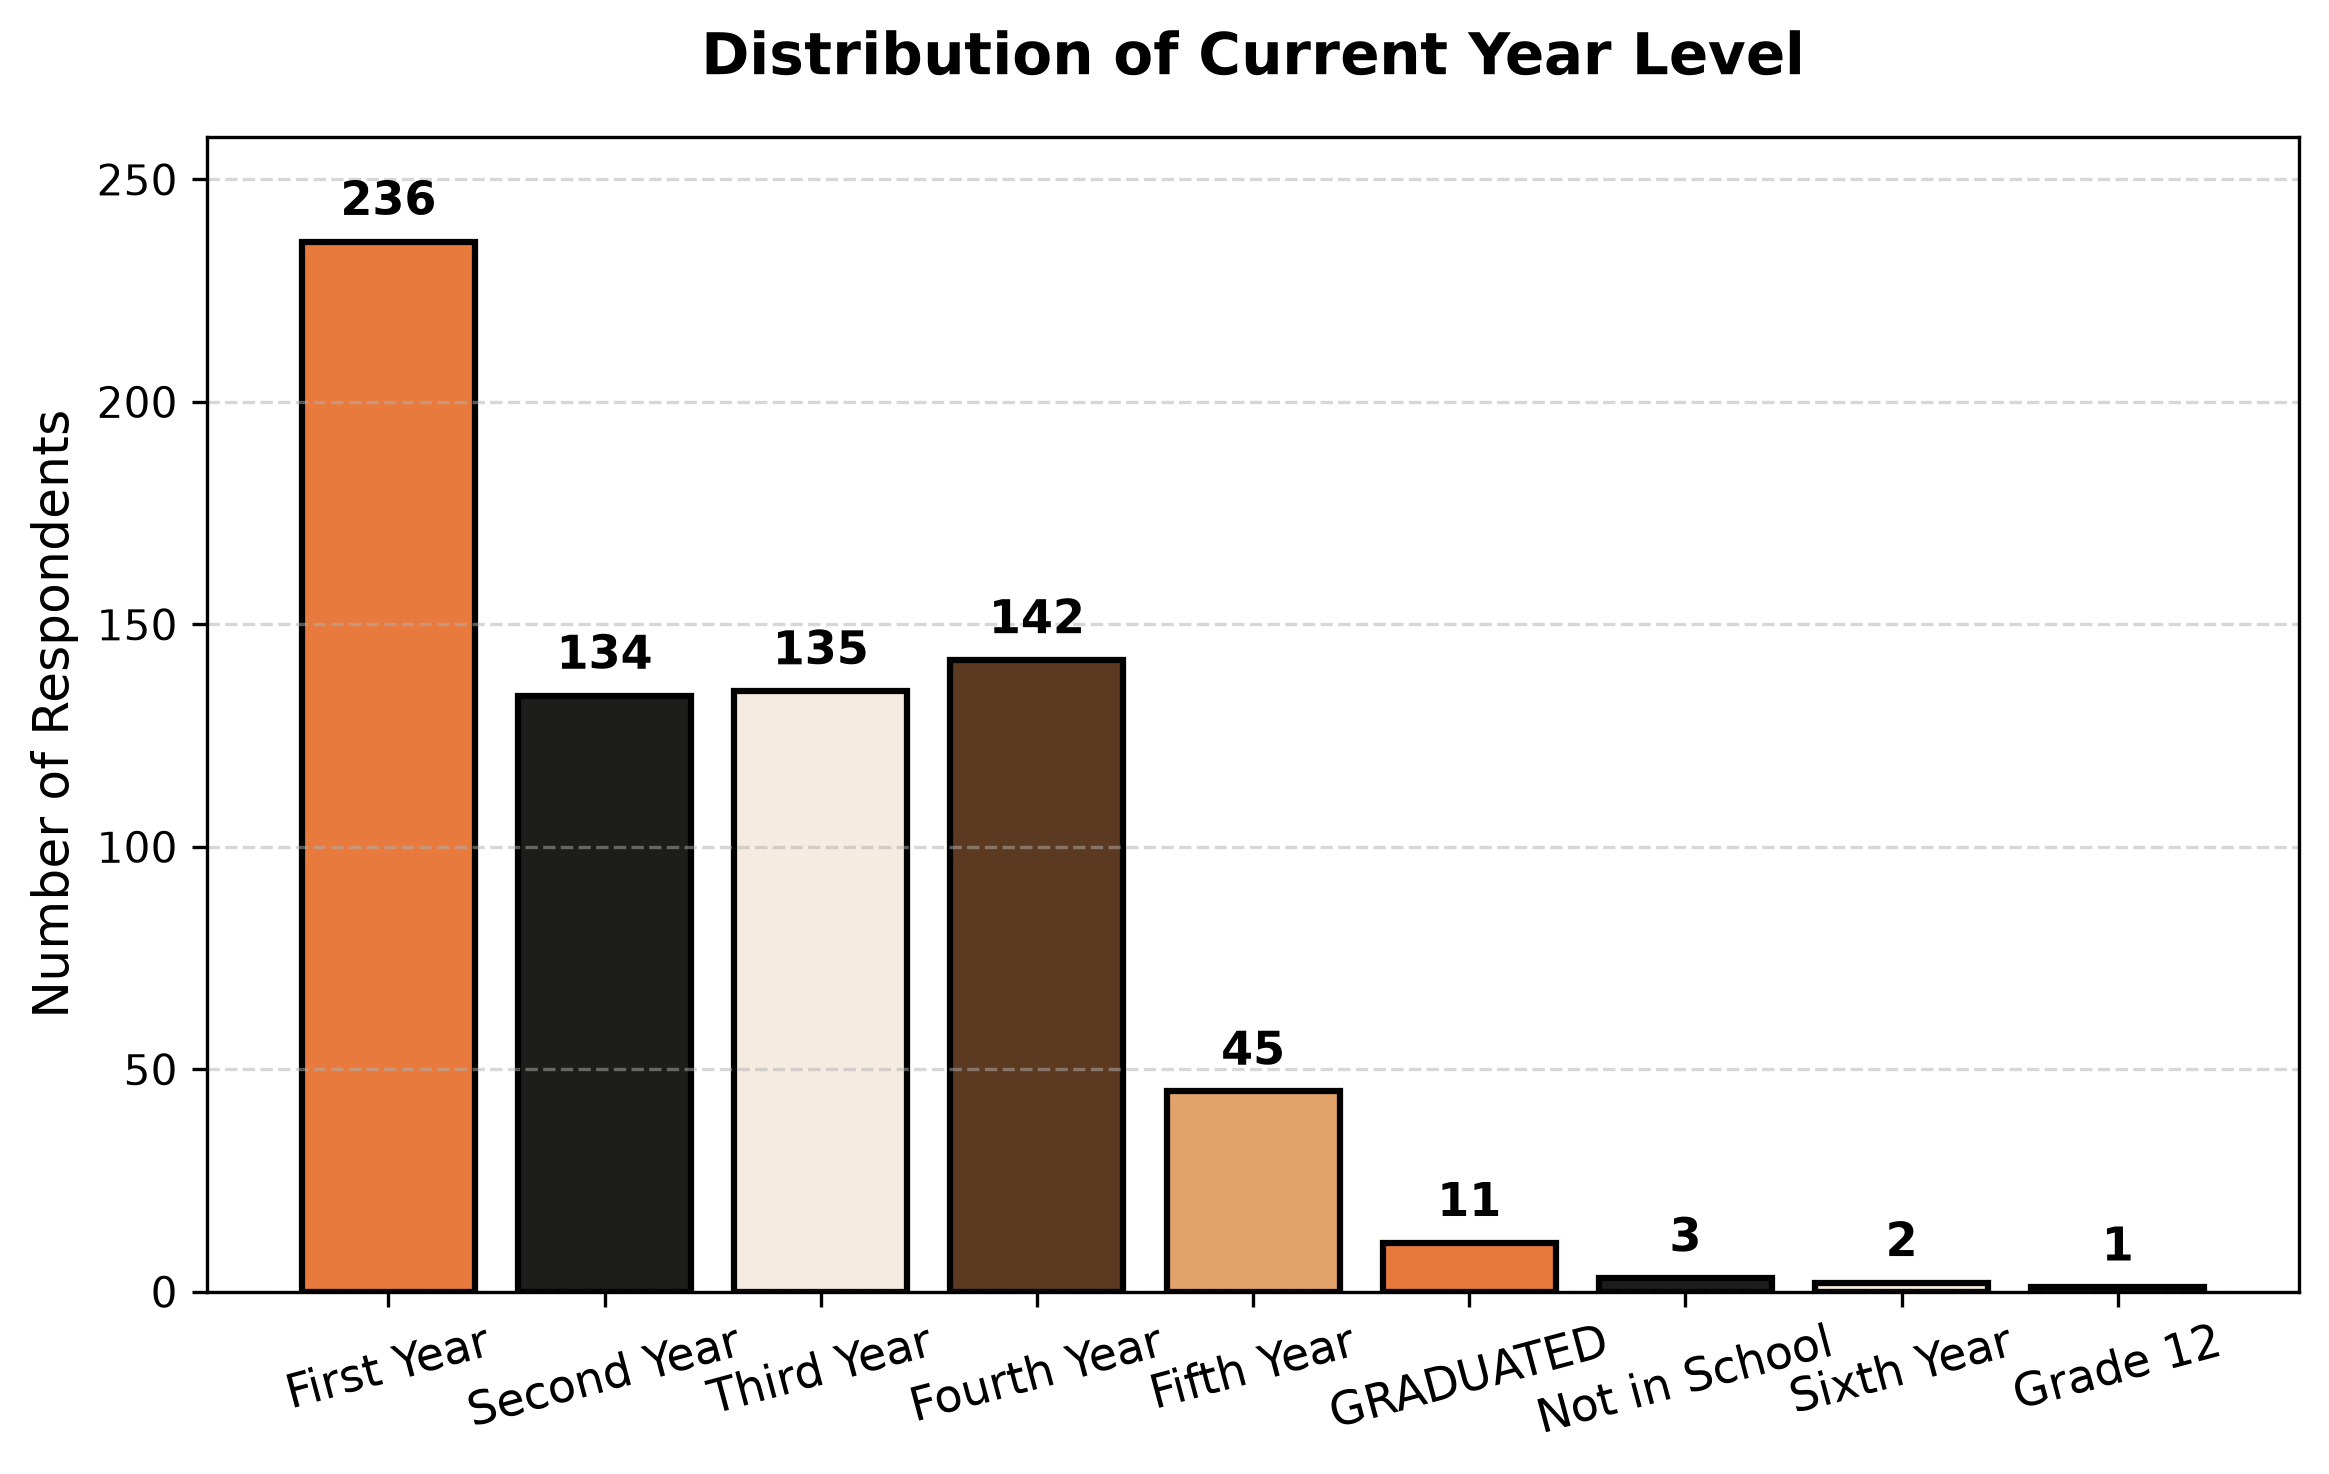

Success! The Year Level chart has been saved to: data_visualization\Year_Level_Distribution.png


In [5]:
import os
import matplotlib.pyplot as plt
import pandas as pd

# 1. Load the data and grab Column 5
cleaned_df = pd.read_csv("rawdata/Cleaned_Data.csv")
year_col = cleaned_df.columns[5]

# Count the respondents for each year level
counts = cleaned_df[year_col].value_counts()

# --- PRO TRICK: FORCE LOGICAL ORDER ---
# Pandas usually sorts from biggest to smallest. We want chronological order!
correct_order = [
    "First Year",
    "Second Year",
    "Third Year",
    "Fourth Year",
    "Forth Year",
    "Fifth Year",
    "Not Specified",
    "TESDA",
]

# Filter our list to only include answers that actually exist in your data, in the correct order
ordered_labels = [level for level in correct_order if level in counts.index]
# Add any unexpected answers to the end
ordered_labels += [level for level in counts.index if level not in correct_order]

# Re-sort our counts to match this perfect logical order
counts = counts.reindex(ordered_labels)

# 2. Set up the figure
plt.figure(figsize=(9, 5), dpi=300)

calico_colors = ['#E87A3E', '#1D1D1B', '#F5EBE1', '#5C3A21', '#E2A36B']
# Loop the colors to match however many bars we have
colors = [calico_colors[i % len(calico_colors)] for i in range(len(counts))]

# 3. Create the Bar Chart
bars = plt.bar(
    counts.index, counts.values, color=colors, edgecolor='black', linewidth=1.5
)

# Give it 10% breathing room at the top
plt.ylim(0, counts.max() * 1.1)

# 4. Add the exact numbers on top of the bars!
for bar in bars:
    height = bar.get_height()
    if height > 0:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + (counts.max() * 0.015),
            str(int(height)),
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='bold',
        )

# 5. Add academic labels
plt.title(
    "Distribution of Current Year Level",
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.ylabel("Number of Respondents", fontsize=12)

# Tilt the x-axis labels slightly if they are too long
plt.xticks(rotation=15, fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 6. Save to the specific folder
save_folder = "data_visualization"
os.makedirs(save_folder, exist_ok=True)

file_path = os.path.join(save_folder, "Year_Level_Distribution.png")
plt.savefig(file_path, dpi=300, bbox_inches='tight')

plt.show()

print(f"Success! The Year Level chart has been saved to: {file_path}")

C:\Users\Nitro\AppData\Local\Temp\ipykernel_125648\2892606101.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


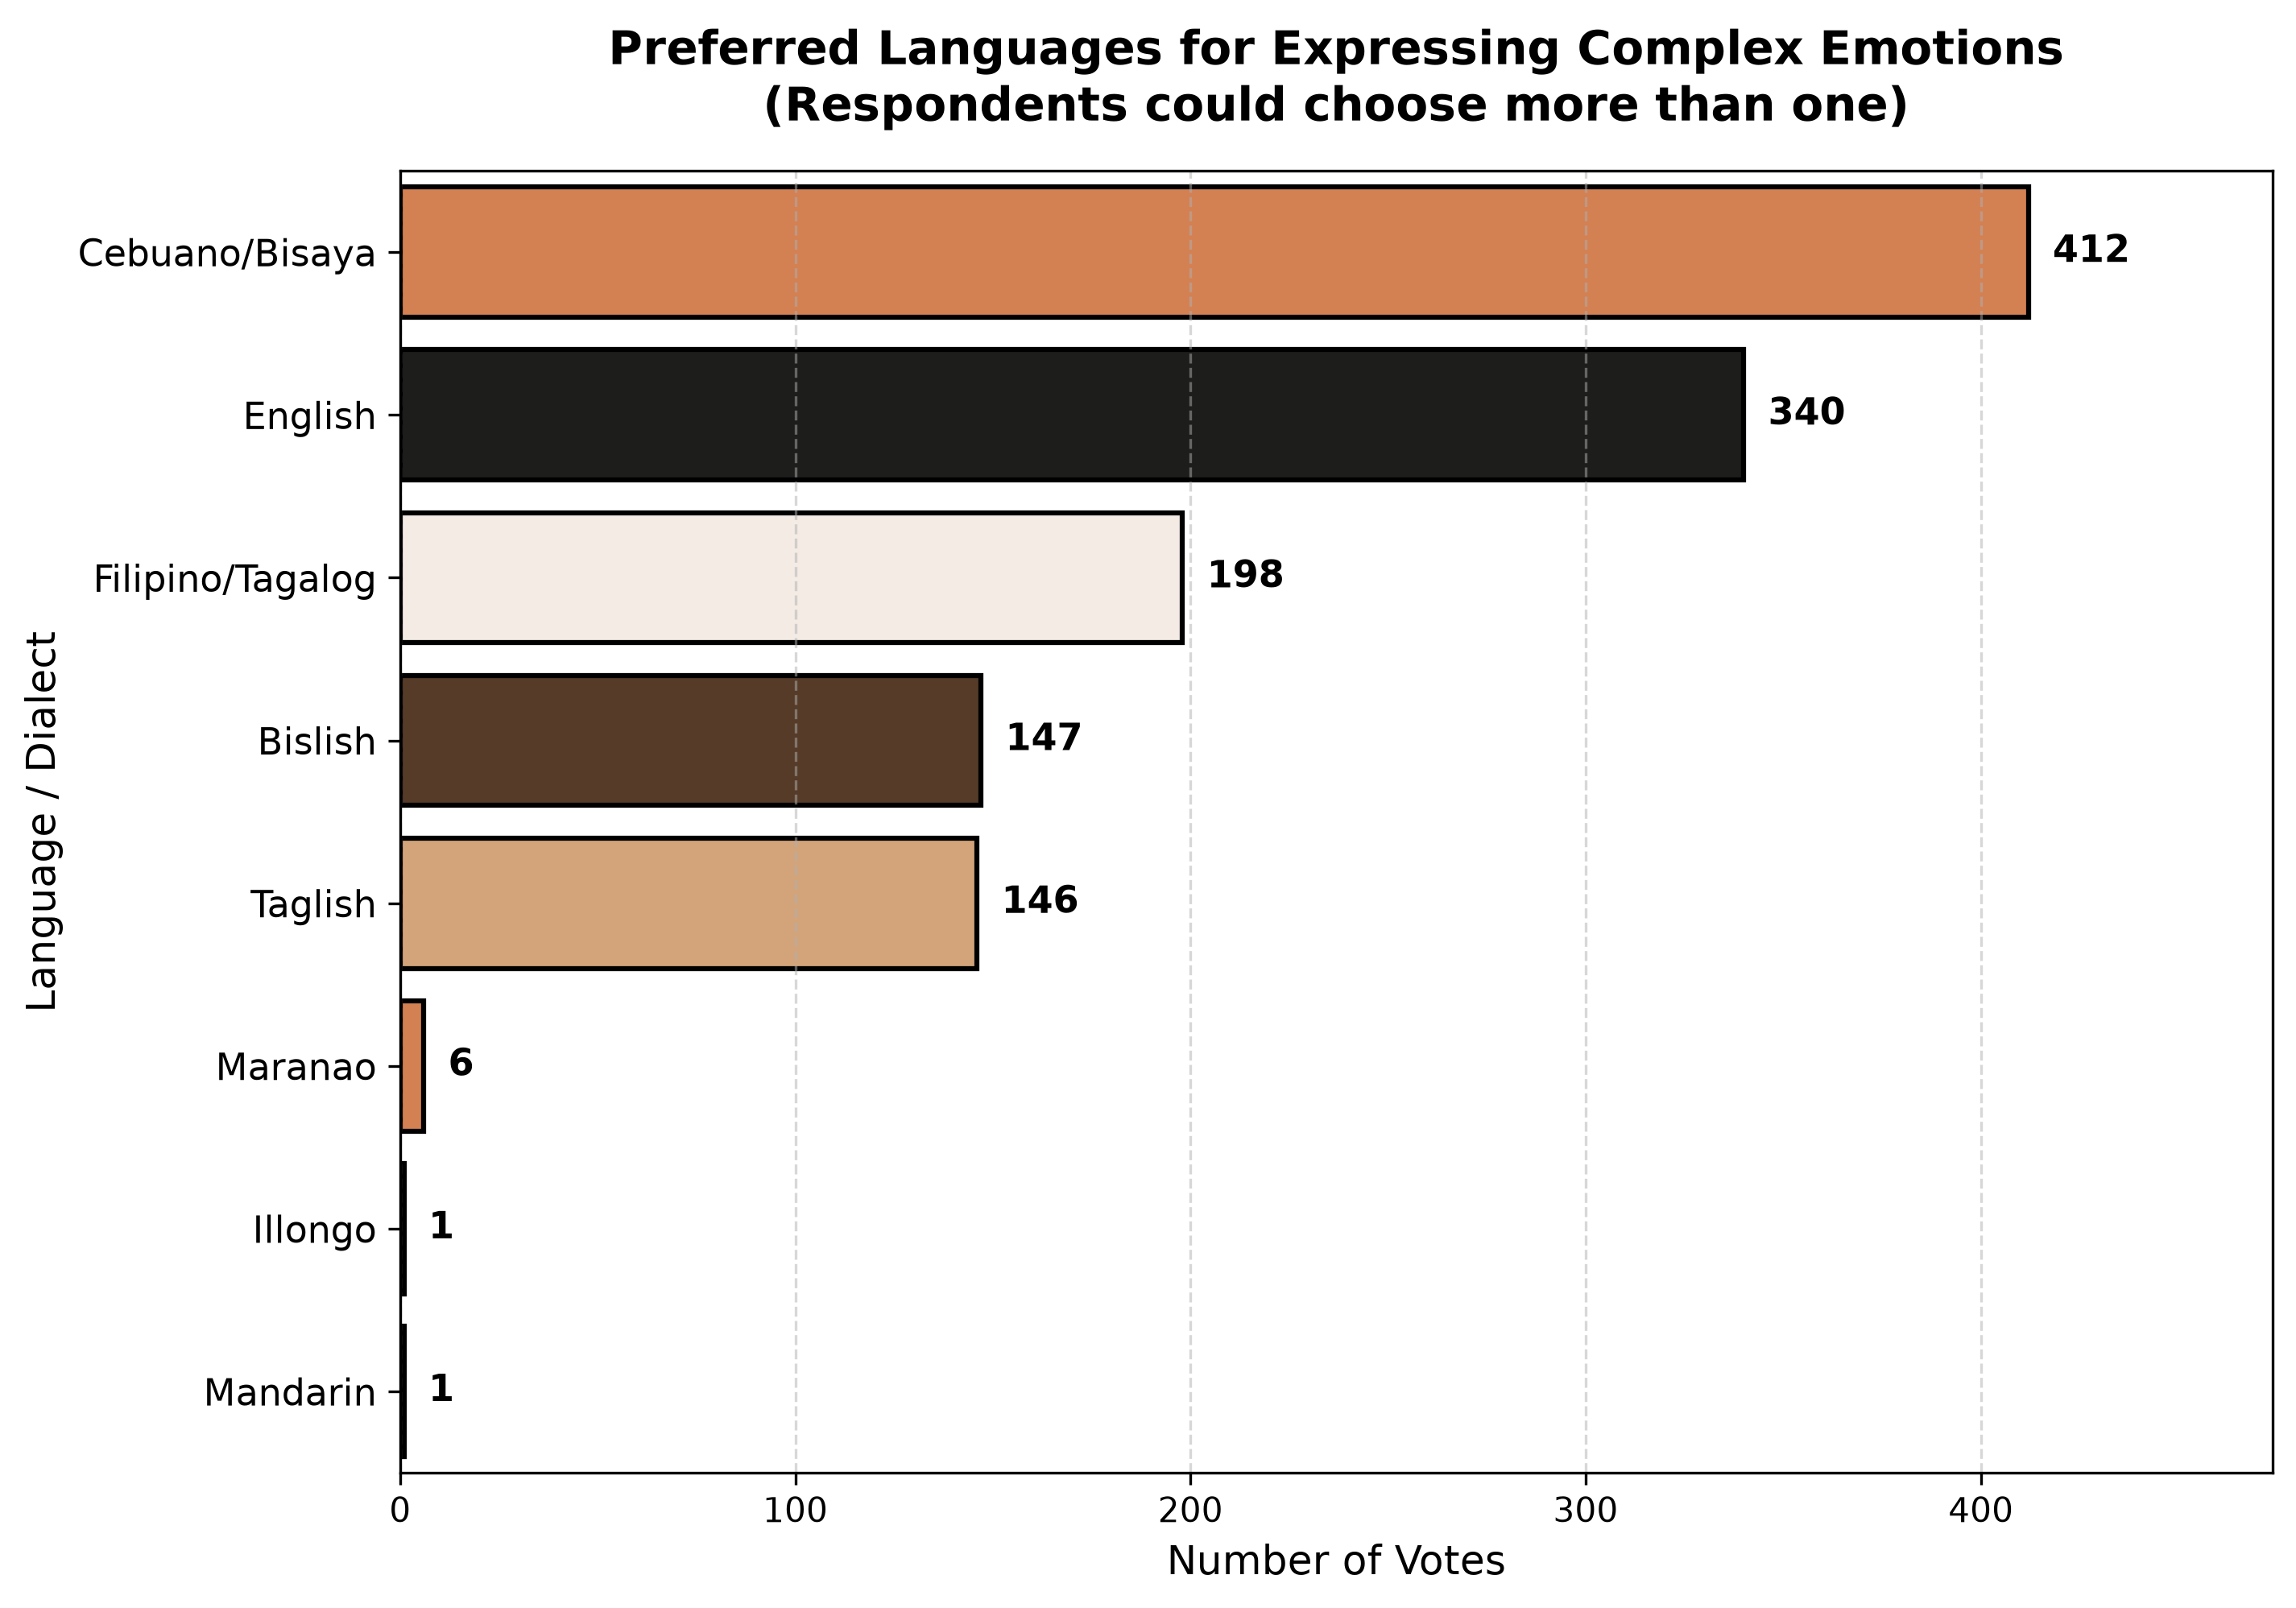

Success! The Language Preferences chart has been saved to: data_visualization\Language_Preferences.png


In [18]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Load the data and grab Column 7 (Index 6)
cleaned_df = pd.read_csv("rawdata/Cleaned_Data.csv")
lang_col = cleaned_df.columns[6]

# 2. SPLIT THE MULTIPLE ANSWERS
separated_languages = (
    cleaned_df[lang_col]
    .dropna()
    .astype(str)
    .str.split(",")
    .explode()
)

# 3. Clean up any accidental spaces
separated_languages = separated_languages.str.strip()

# 4. Count the individual languages
language_counts = separated_languages.value_counts().reset_index()
language_counts.columns = ["Language", "Count"]

# 5. Set up the figure with High Resolution
plt.figure(figsize=(10, 7), dpi=300)

# The Calico Theme Palette
calico_colors = ["#E87A3E", "#1D1D1B", "#F5EBE1", "#5C3A21", "#E2A36B"]
# Loop the colors to match however many bars we have in case there are a lot of languages
colors = [calico_colors[i % len(calico_colors)] for i in range(len(language_counts))]

# 6. Create the Horizontal Bar Chart using Seaborn
ax = sns.barplot(
    data=language_counts,
    x="Count",
    y="Language",
    palette=colors,
    edgecolor="black",  # Adds the Calico-style black borders
    linewidth=1.5,
)

# Give it 15% breathing room on the right side so our numbers fit nicely
max_count = language_counts["Count"].max()
plt.xlim(0, max_count * 1.15)

# 7. Add the exact numbers to the right of the bars!
for patch in ax.patches:
    width = patch.get_width()
    if width > 0:
        plt.text(
            width + (max_count * 0.015),             # X position (just to the right of the bar)
            patch.get_y() + patch.get_height() / 2,   # Y position (vertically centered)
            str(int(width)),
            ha="left",
            va="center",
            fontsize=11,
            fontweight="bold",
        )

# 8. Add academic labels and styling
plt.title(
    "Preferred Languages for Expressing Complex Emotions\n(Respondents could choose more than one)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Number of Votes", fontsize=12)
plt.ylabel("Language / Dialect", fontsize=12)

# Make the y-axis text slightly bigger for readability
plt.yticks(fontsize=11)

# Add a subtle grid behind the bars (vertical lines)
plt.grid(axis="x", linestyle="--", alpha=0.5)

# 9. Save to the specific folder
save_folder = "data_visualization"
os.makedirs(save_folder, exist_ok=True)

file_path = os.path.join(save_folder, "Language_Preferences.png")
plt.savefig(file_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Success! The Language Preferences chart has been saved to: {file_path}")

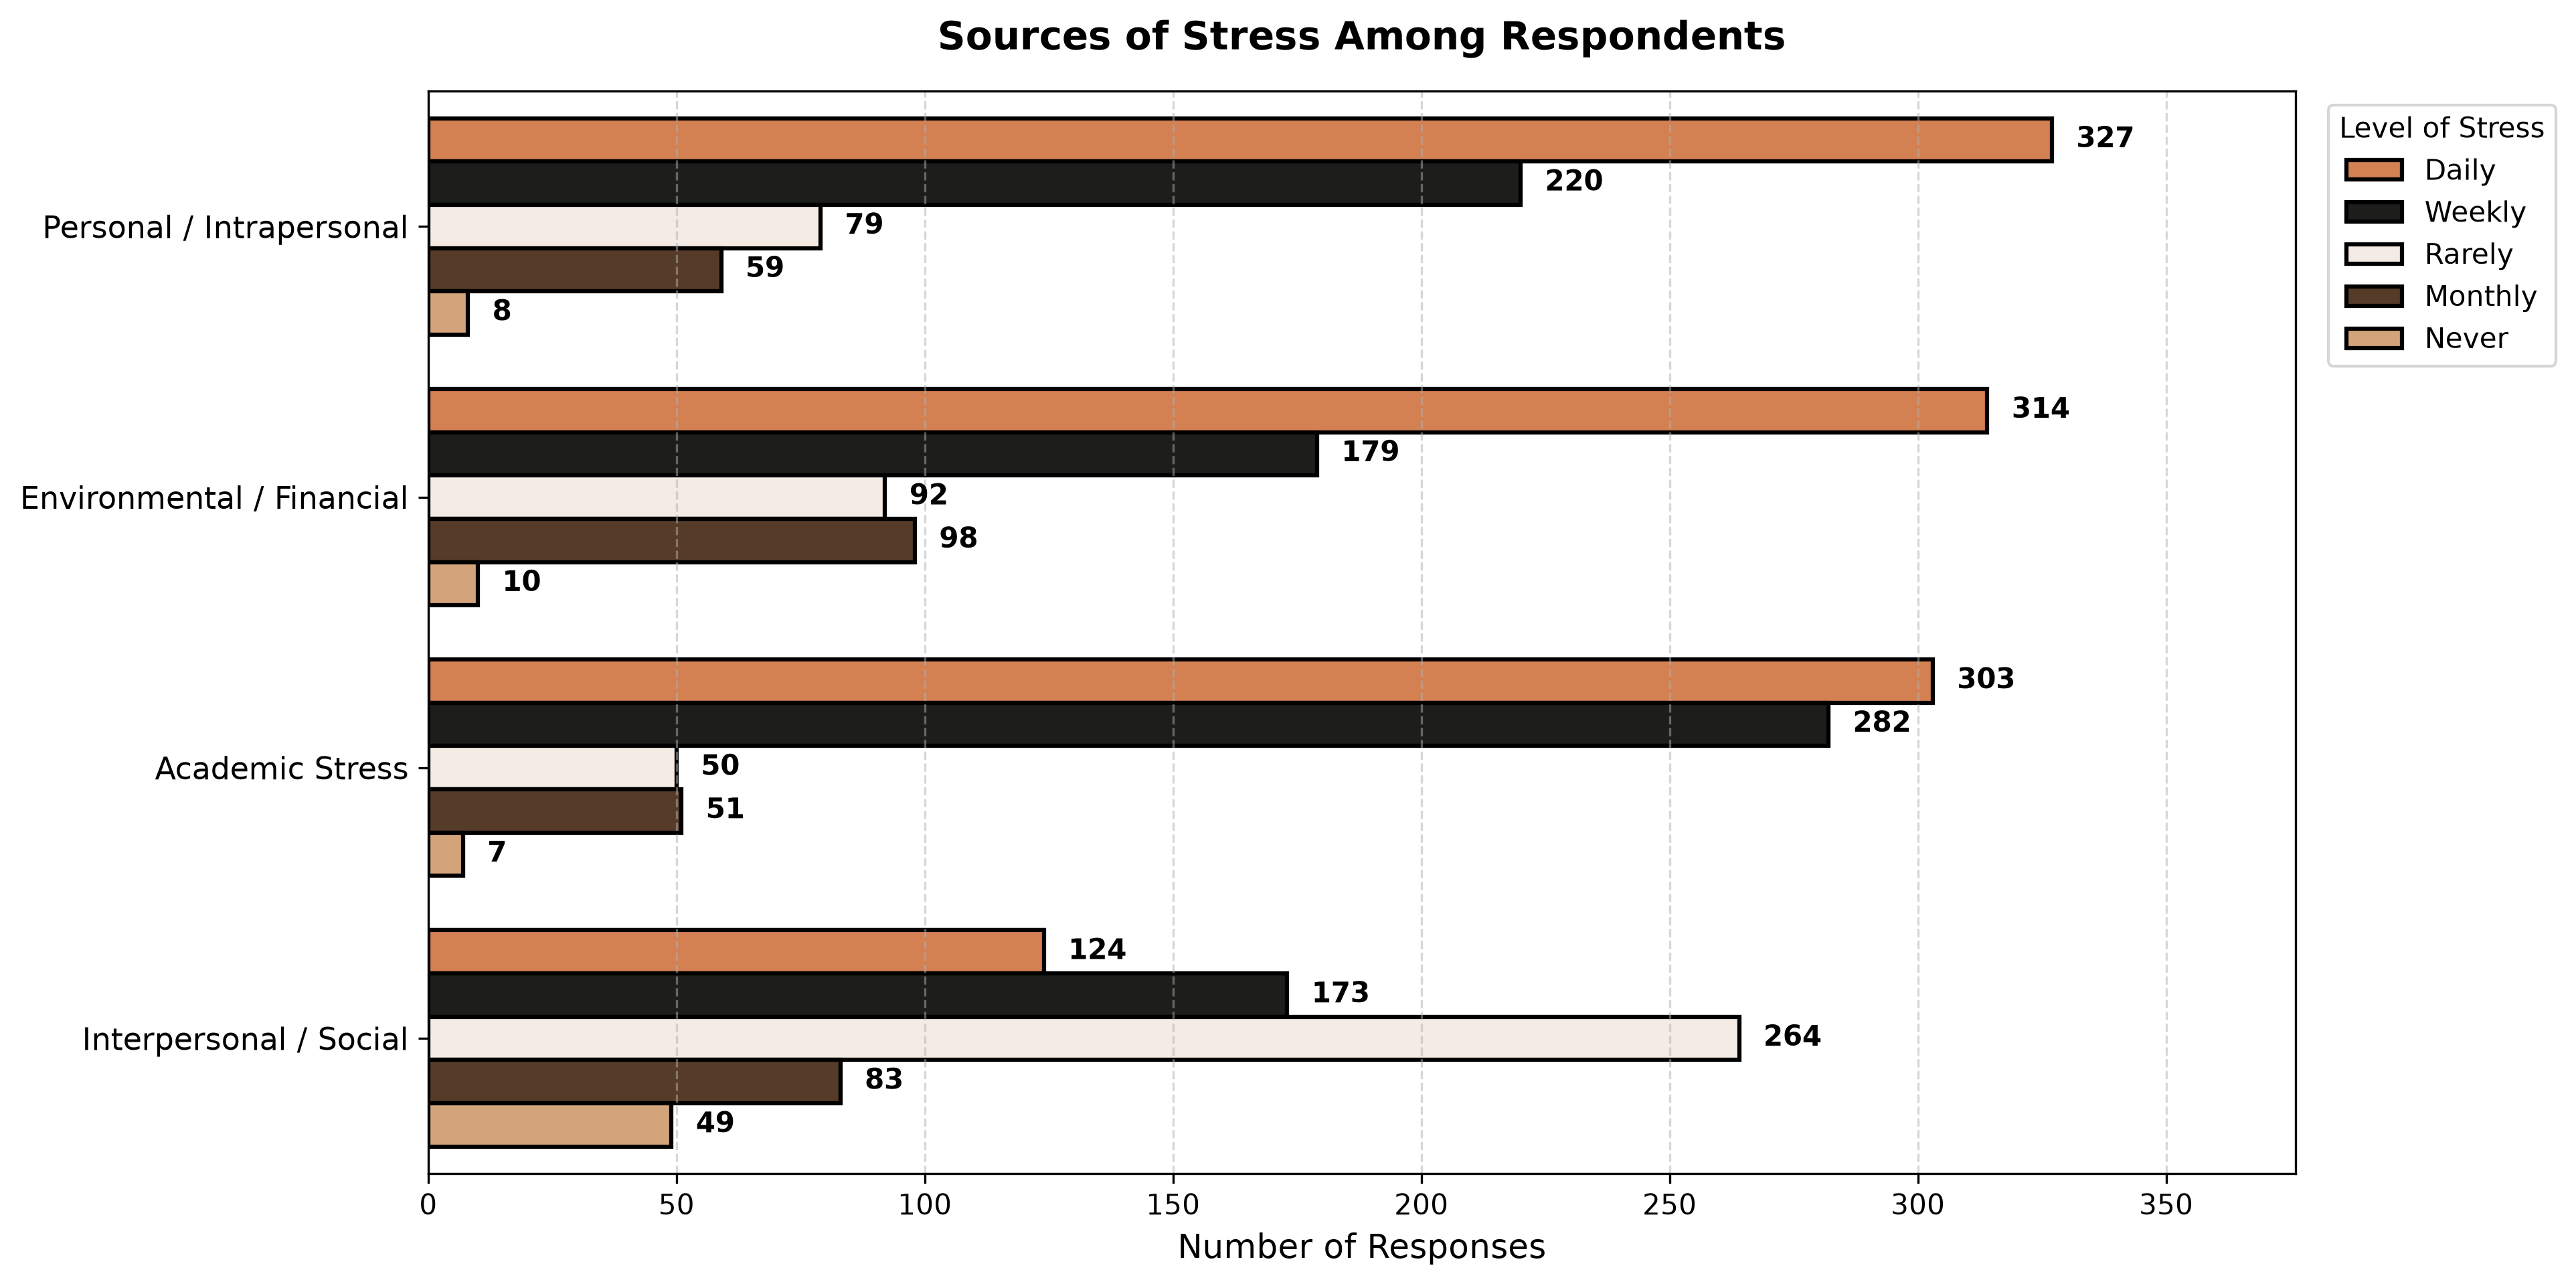

Success! The Stress Sources chart has been saved to: data_visualization\Stress_Sources_Grouped.png


In [20]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Load the dataset
cleaned_df = pd.read_csv("rawdata/Cleaned_Data.csv")

# 2. Define the exact columns for the 4 stress types (Indexes 7, 8, 9, 10)
stress_cols = [
    cleaned_df.columns[7],
    cleaned_df.columns[8],
    cleaned_df.columns[9],
    cleaned_df.columns[10],
]

# We will give them shorter names for the chart labels
short_names = {
    stress_cols[0]: "Academic Stress",
    stress_cols[1]: "Personal / Intrapersonal",
    stress_cols[2]: "Interpersonal / Social",
    stress_cols[3]: "Environmental / Financial",
}

# Temporarily rename them just for this graph
temp_df = cleaned_df[stress_cols].rename(columns=short_names)

# 3. RESTRUCTURE THE DATA FOR SEABORN
# Seaborn grouped charts require "melted" data (turning the 4 columns into 2 neat columns)
melted_df = temp_df.melt(var_name="Stress Type", value_name="Response")

# Count how many people gave each response for each stress type
stress_counts = melted_df.value_counts().reset_index(name="Count")

# 4. Set up the figure with High Resolution
plt.figure(figsize=(12, 7), dpi=300)

# The Calico Theme Palette
calico_colors = ["#E87A3E", "#1D1D1B", "#F5EBE1", "#5C3A21", "#E2A36B"]

# 5. Create the Grouped Bar Chart using Seaborn
# Using 'hue="Response"' tells Seaborn to put the answers side-by-side!
ax = sns.barplot(
    data=stress_counts,
    x="Count",
    y="Stress Type",
    hue="Response",
    palette=calico_colors,
    edgecolor="black",  # Adds the Calico-style black borders
    linewidth=1.5,
)

# Give it 15% breathing room on the right side so our numbers fit nicely
max_count = stress_counts["Count"].max()
plt.xlim(0, max_count * 1.15)

# 6. Add the exact numbers to the right of the bars!
for patch in ax.patches:
    width = patch.get_width()
    # Seaborn sometimes draws invisible bars for missing categories, so we check if width > 0
    if width > 0:
        plt.text(
            width + (max_count * 0.015),             # X position (just to the right of the bar)
            patch.get_y() + patch.get_height() / 2,   # Y position (vertically centered)
            str(int(width)),
            ha="left",
            va="center",
            fontsize=10,
            fontweight="bold",
        )

# 7. Add academic labels and styling
plt.title(
    "Sources of Stress Among Respondents",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Number of Responses", fontsize=12)
plt.ylabel("", fontsize=12)  # Hidden because the categories are obvious

# Make the y-axis text slightly bigger for readability
plt.yticks(fontsize=11)

# Move the Legend outside the chart so it doesn't block the data
plt.legend(title="Level of Stress", bbox_to_anchor=(1.01, 1), loc="upper left")

# Add a subtle grid behind the bars (vertical lines)
plt.grid(axis="x", linestyle="--", alpha=0.5)

# 8. Save to the specific folder
save_folder = "data_visualization"
os.makedirs(save_folder, exist_ok=True)

file_path = os.path.join(save_folder, "Stress_Sources_Grouped.png")
plt.savefig(file_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Success! The Stress Sources chart has been saved to: {file_path}")

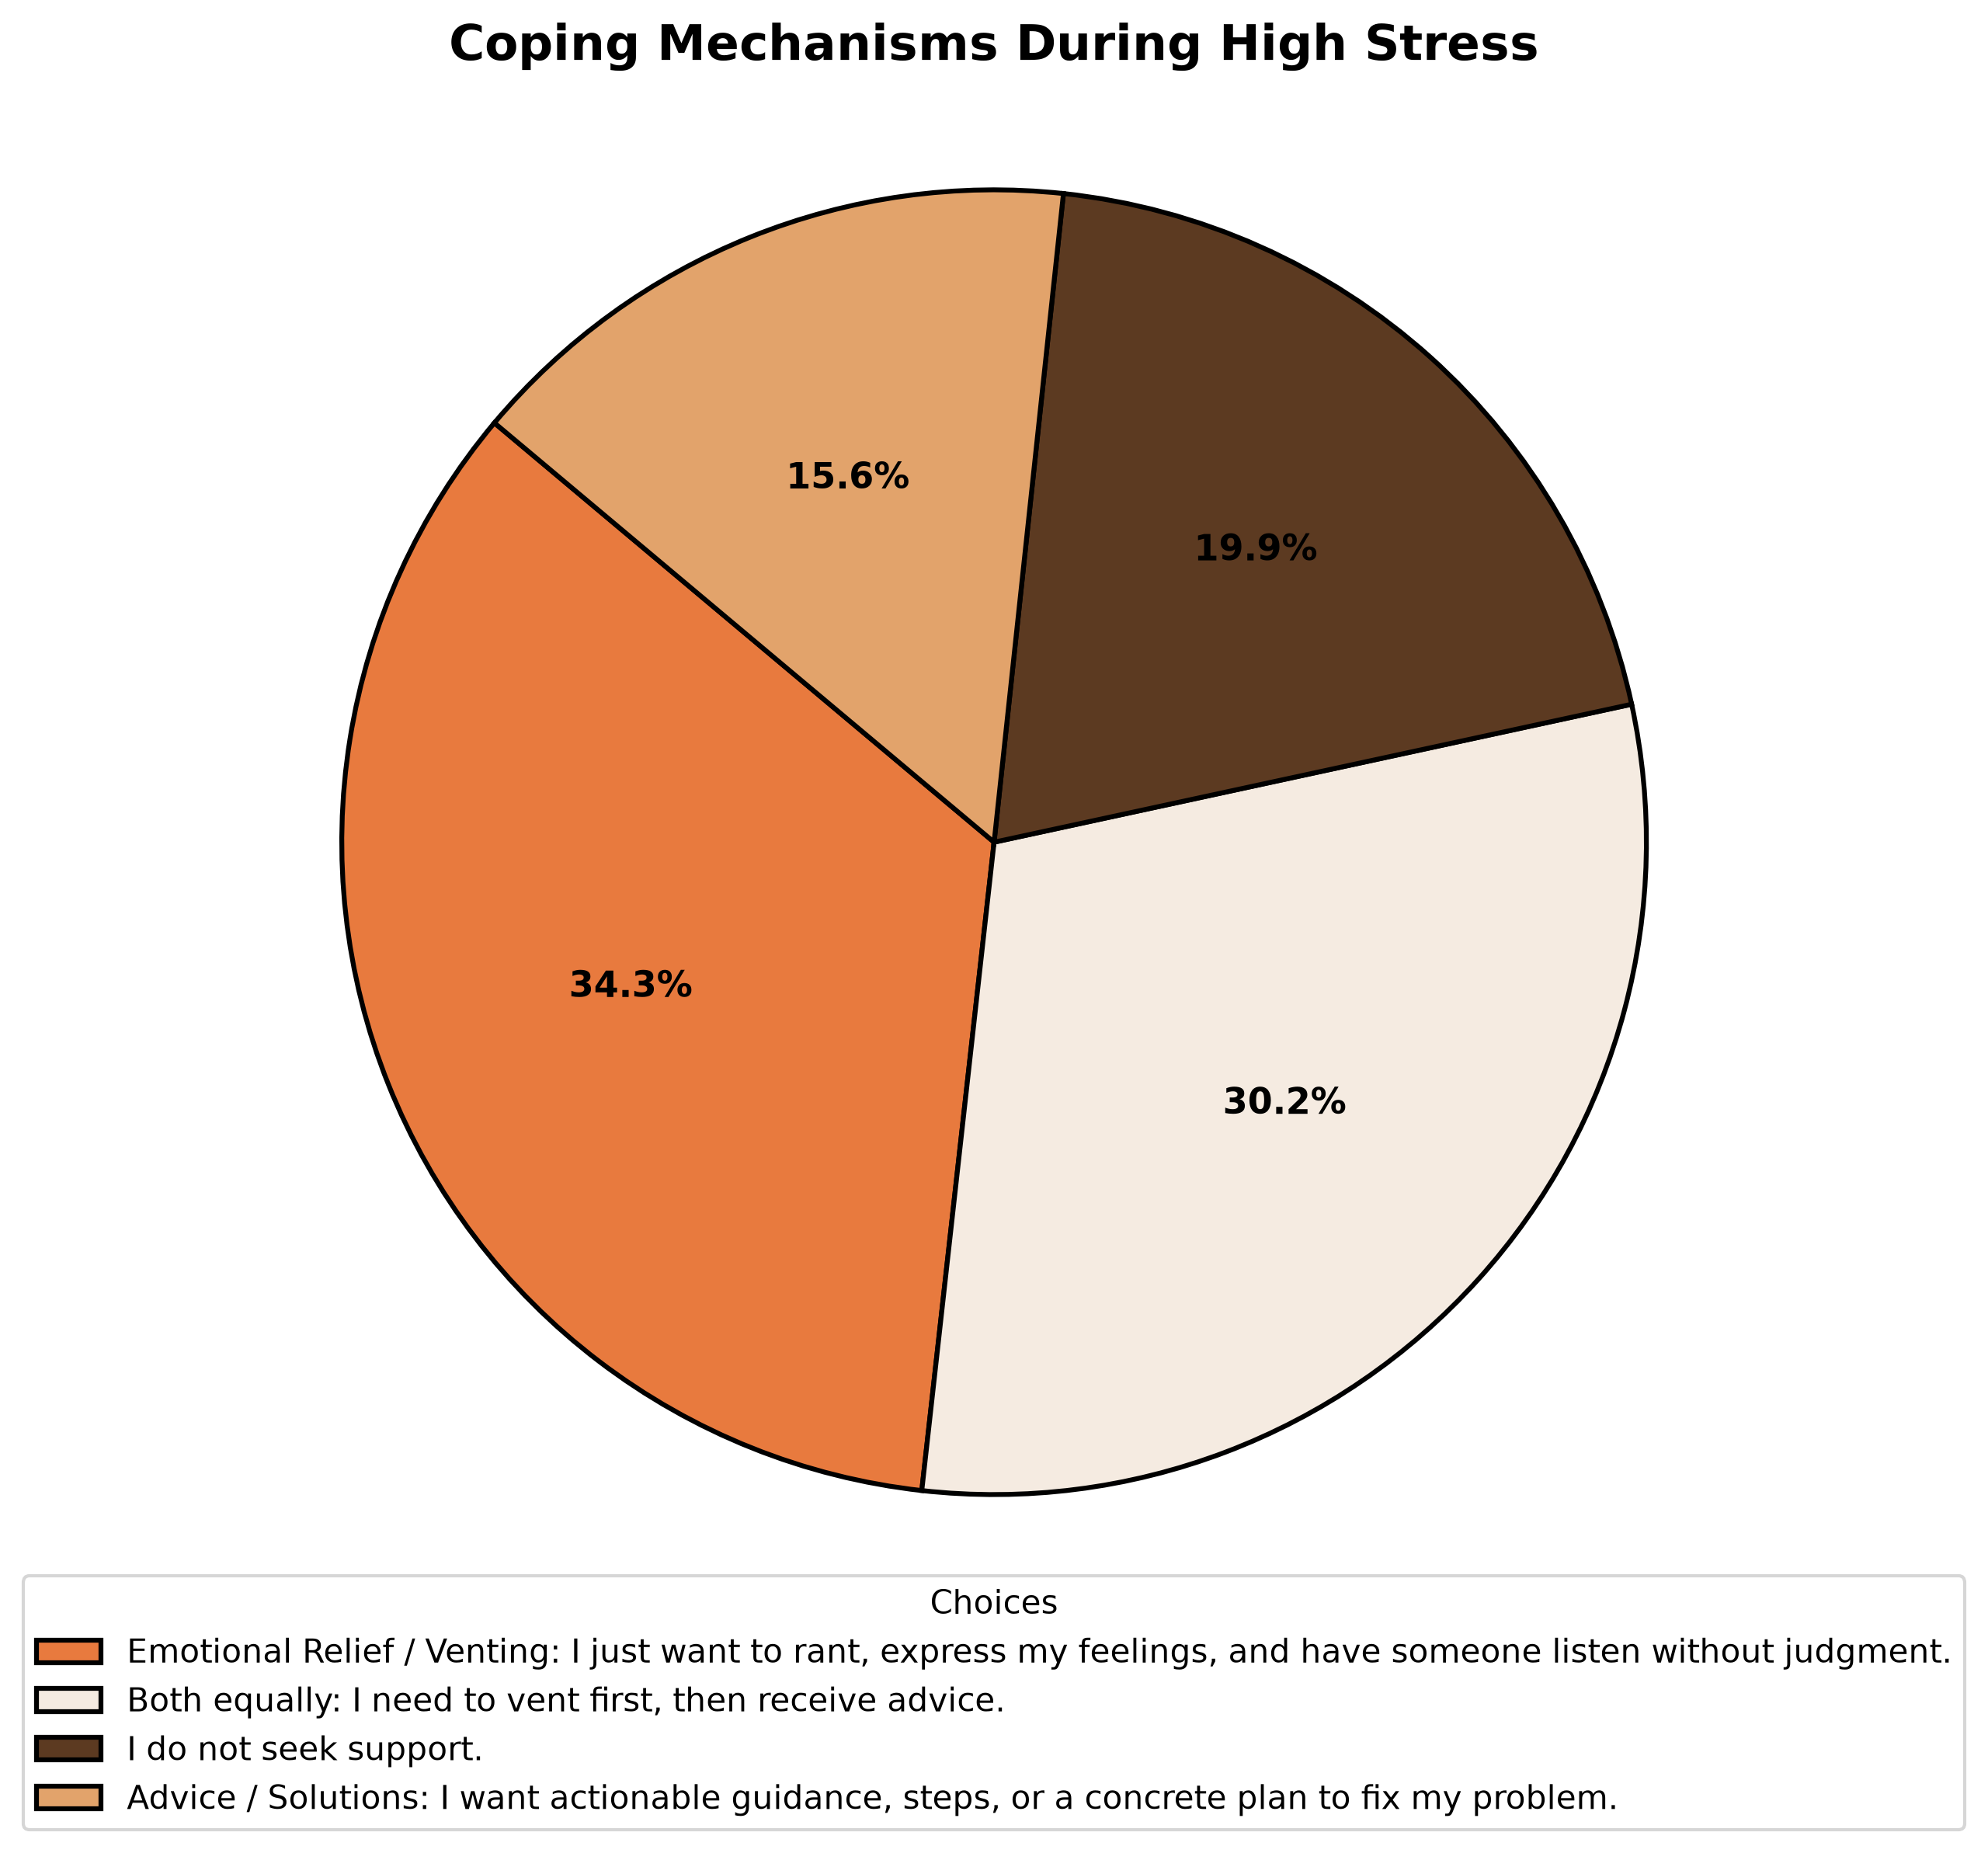

Success! The Pie Chart has been saved to: data_visualization\Coping_Mechanisms_Pie.png


In [26]:
import os
import matplotlib.pyplot as plt
import pandas as pd

# 1. Load the dataset
cleaned_df = pd.read_csv("rawdata/Cleaned_Data.csv")

# 2. Grab Column 12 (Index 11)
coping_col = cleaned_df.columns[11]

# 3. Count the answers (Assuming they only picked ONE answer each)
answer_counts = cleaned_df[coping_col].dropna().value_counts()
labels = answer_counts.index
sizes = answer_counts.values

# 4. Set up the figure (Made it slightly taller so the legend fits nicely below)
plt.figure(figsize=(10, 8), dpi=300)

# The Calico Theme Palette
calico_colors = ["#E87A3E", "#F5EBE1", "#5C3A21", "#E2A36B", "#1D1D1B"]
colors = [calico_colors[i % len(calico_colors)] for i in range(len(answer_counts))]

# 5. Create the Pie Chart
# We removed 'labels=labels' so the text doesn't show up on the sides.
# We also save the 'wedges' so we can use them to build the legend later!
wedges, texts, autotexts = plt.pie(
    sizes,
    colors=colors,
    autopct="%1.1f%%",  # Automatically calculates percentages
    startangle=140,  # Rotates it slightly for a better look
    wedgeprops={"edgecolor": "black", "linewidth": 1.5},
    textprops={"fontsize": 11, "fontweight": "bold"},
)

# 6. Add title and styling
plt.title(
    "Coping Mechanisms During High Stress",
    fontsize=15,
    fontweight="bold",
    pad=20,
)

# This ensures the pie is drawn as a perfect circle
plt.axis("equal")

# 7. Add the Legend at the Bottom
plt.legend(
    wedges,
    labels,
    title="Choices",  # Title for the legend box
    loc="upper center",  # Aligns it to the center
    bbox_to_anchor=(0.5, 0.0),  # Pushes it down below the chart (0.0 is the bottom)
    ncol=1,  # Lists them in 1 vertical column (change to 2 for side-by-side)
    fontsize=10,
)

# 8. Save to the specific folder
save_folder = "data_visualization"
os.makedirs(save_folder, exist_ok=True)

file_path = os.path.join(save_folder, "Coping_Mechanisms_Pie.png")

# bbox_inches="tight" is very important here so the bottom legend doesn't get cut off!
plt.savefig(file_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Success! The Pie Chart has been saved to: {file_path}")

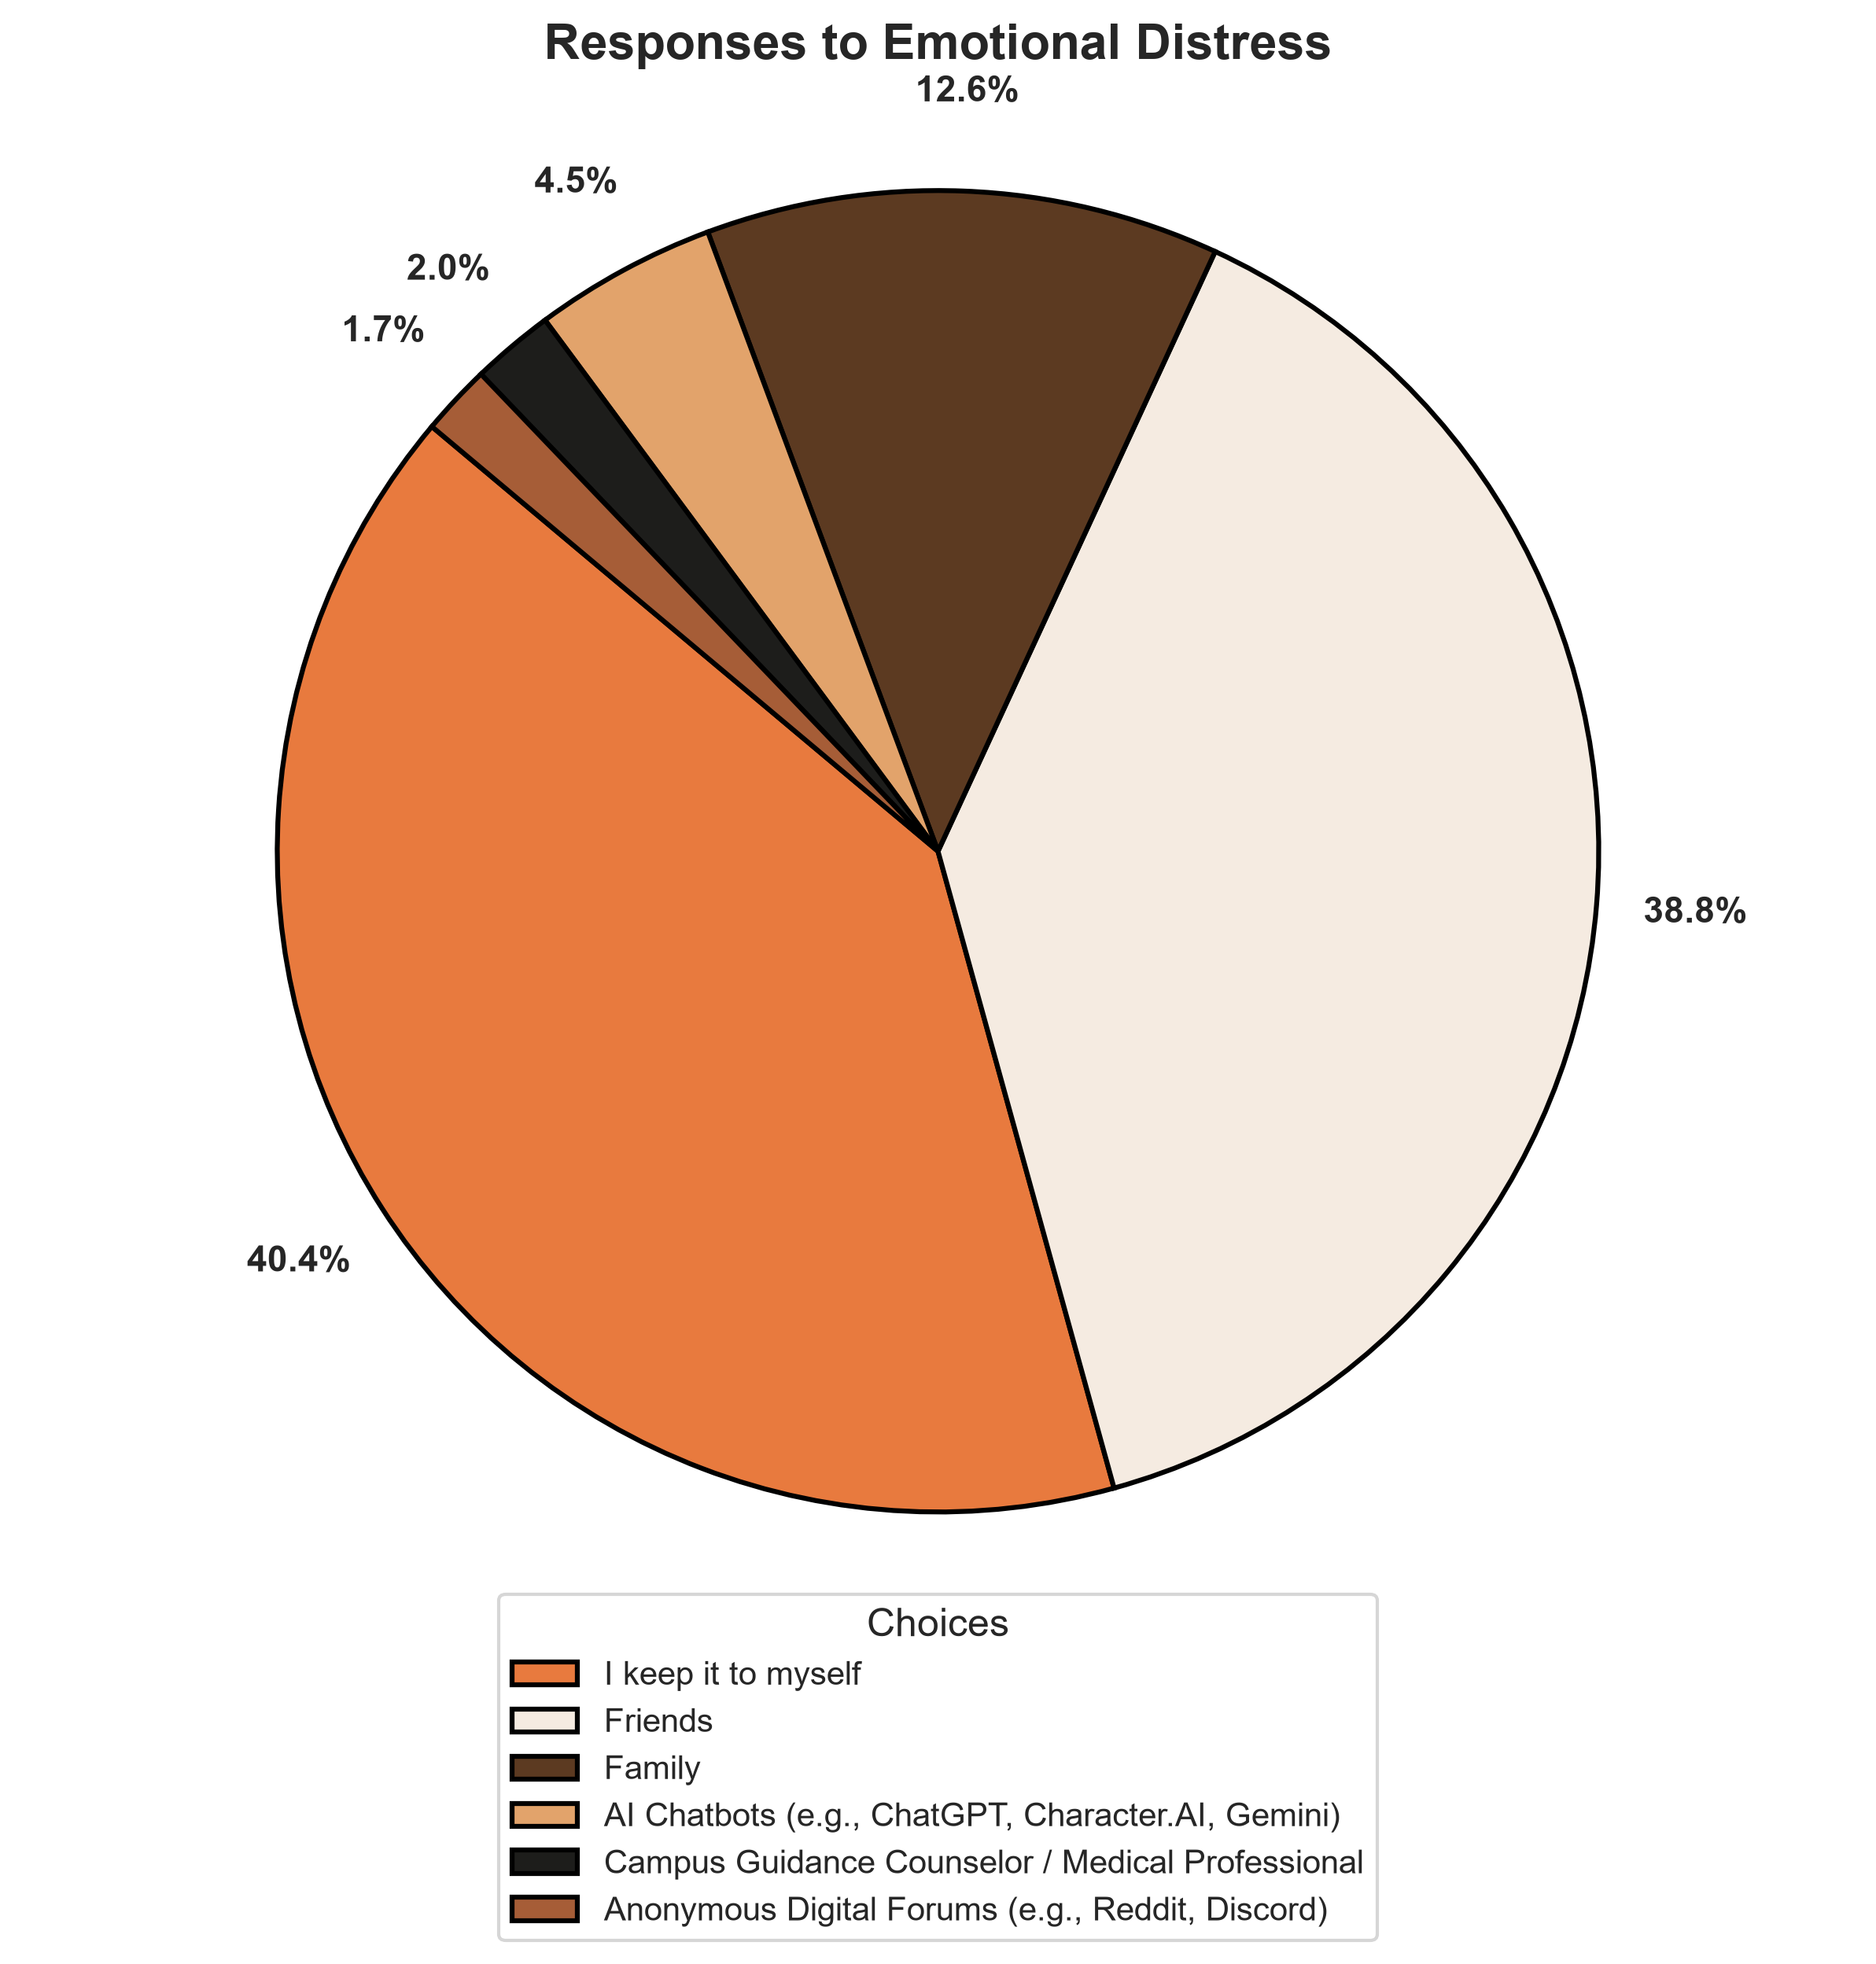

Success! The Pie Chart has been saved to: data_visualization\Emotional_Distress_Pie.png


In [31]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Turn on Seaborn styling for a clean background
sns.set_theme(style="white")

# 2. Load the dataset
cleaned_df = pd.read_csv("rawdata/Cleaned_Data.csv")

# 3. Grab Column 13 (Index 12)
distress_col = cleaned_df.columns[12]

# 4. Count the answers
answer_counts = cleaned_df[distress_col].dropna().value_counts()
labels = answer_counts.index
sizes = answer_counts.values

# 5. Set up the figure (Taller so the legend fits)
plt.figure(figsize=(10, 8), dpi=300)

# The EXTENDED Calico Theme Palette (13 unique earthy colors so they don't repeat!)
extended_calico_colors = [
    "#E87A3E",  # Original Orange
    "#F5EBE1",  # Original Cream
    "#5C3A21",  # Original Brown
    "#E2A36B",  # Original Tan
    "#1D1D1B",  # Original Black
    "#A65D37",  # Rust Brown
    "#D9C3A9",  # Beige
    "#8C4F2B",  # Chocolate
    "#F2C48D",  # Golden Orange
    "#4A3525",  # Espresso
    "#CF8A5F",  # Muted Clay
    "#EBE2D5",  # Off-White
    "#2C1F16",  # Deep Charcoal
]

# Loop them safely just in case
colors = [
    extended_calico_colors[i % len(extended_calico_colors)]
    for i in range(len(answer_counts))
]

# 6. Create the Pie Chart
wedges, texts, autotexts = plt.pie(
    sizes,
    colors=colors,
    autopct="%1.1f%%",
    startangle=140,
    pctdistance=1.15,  # Pushes percentages outside
    wedgeprops={"edgecolor": "black", "linewidth": 1.5},
    textprops={"fontsize": 11, "fontweight": "bold"},
)

# 7. Add title and styling
plt.title(
    "Responses to Emotional Distress",
    fontsize=15,
    fontweight="bold",
    pad=20,
)

plt.axis("equal")

# 8. Add the Legend at the Bottom
plt.legend(
    wedges,
    labels,
    title="Choices",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.0),
    ncol=1,
    fontsize=10,
)

# 9. Save to the specific folder
save_folder = "data_visualization"
os.makedirs(save_folder, exist_ok=True)

file_path = os.path.join(save_folder, "Emotional_Distress_Pie.png")

# bbox_inches="tight" ensures the bottom legend doesn't get cut off!
plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Success! The Pie Chart has been saved to: {file_path}")

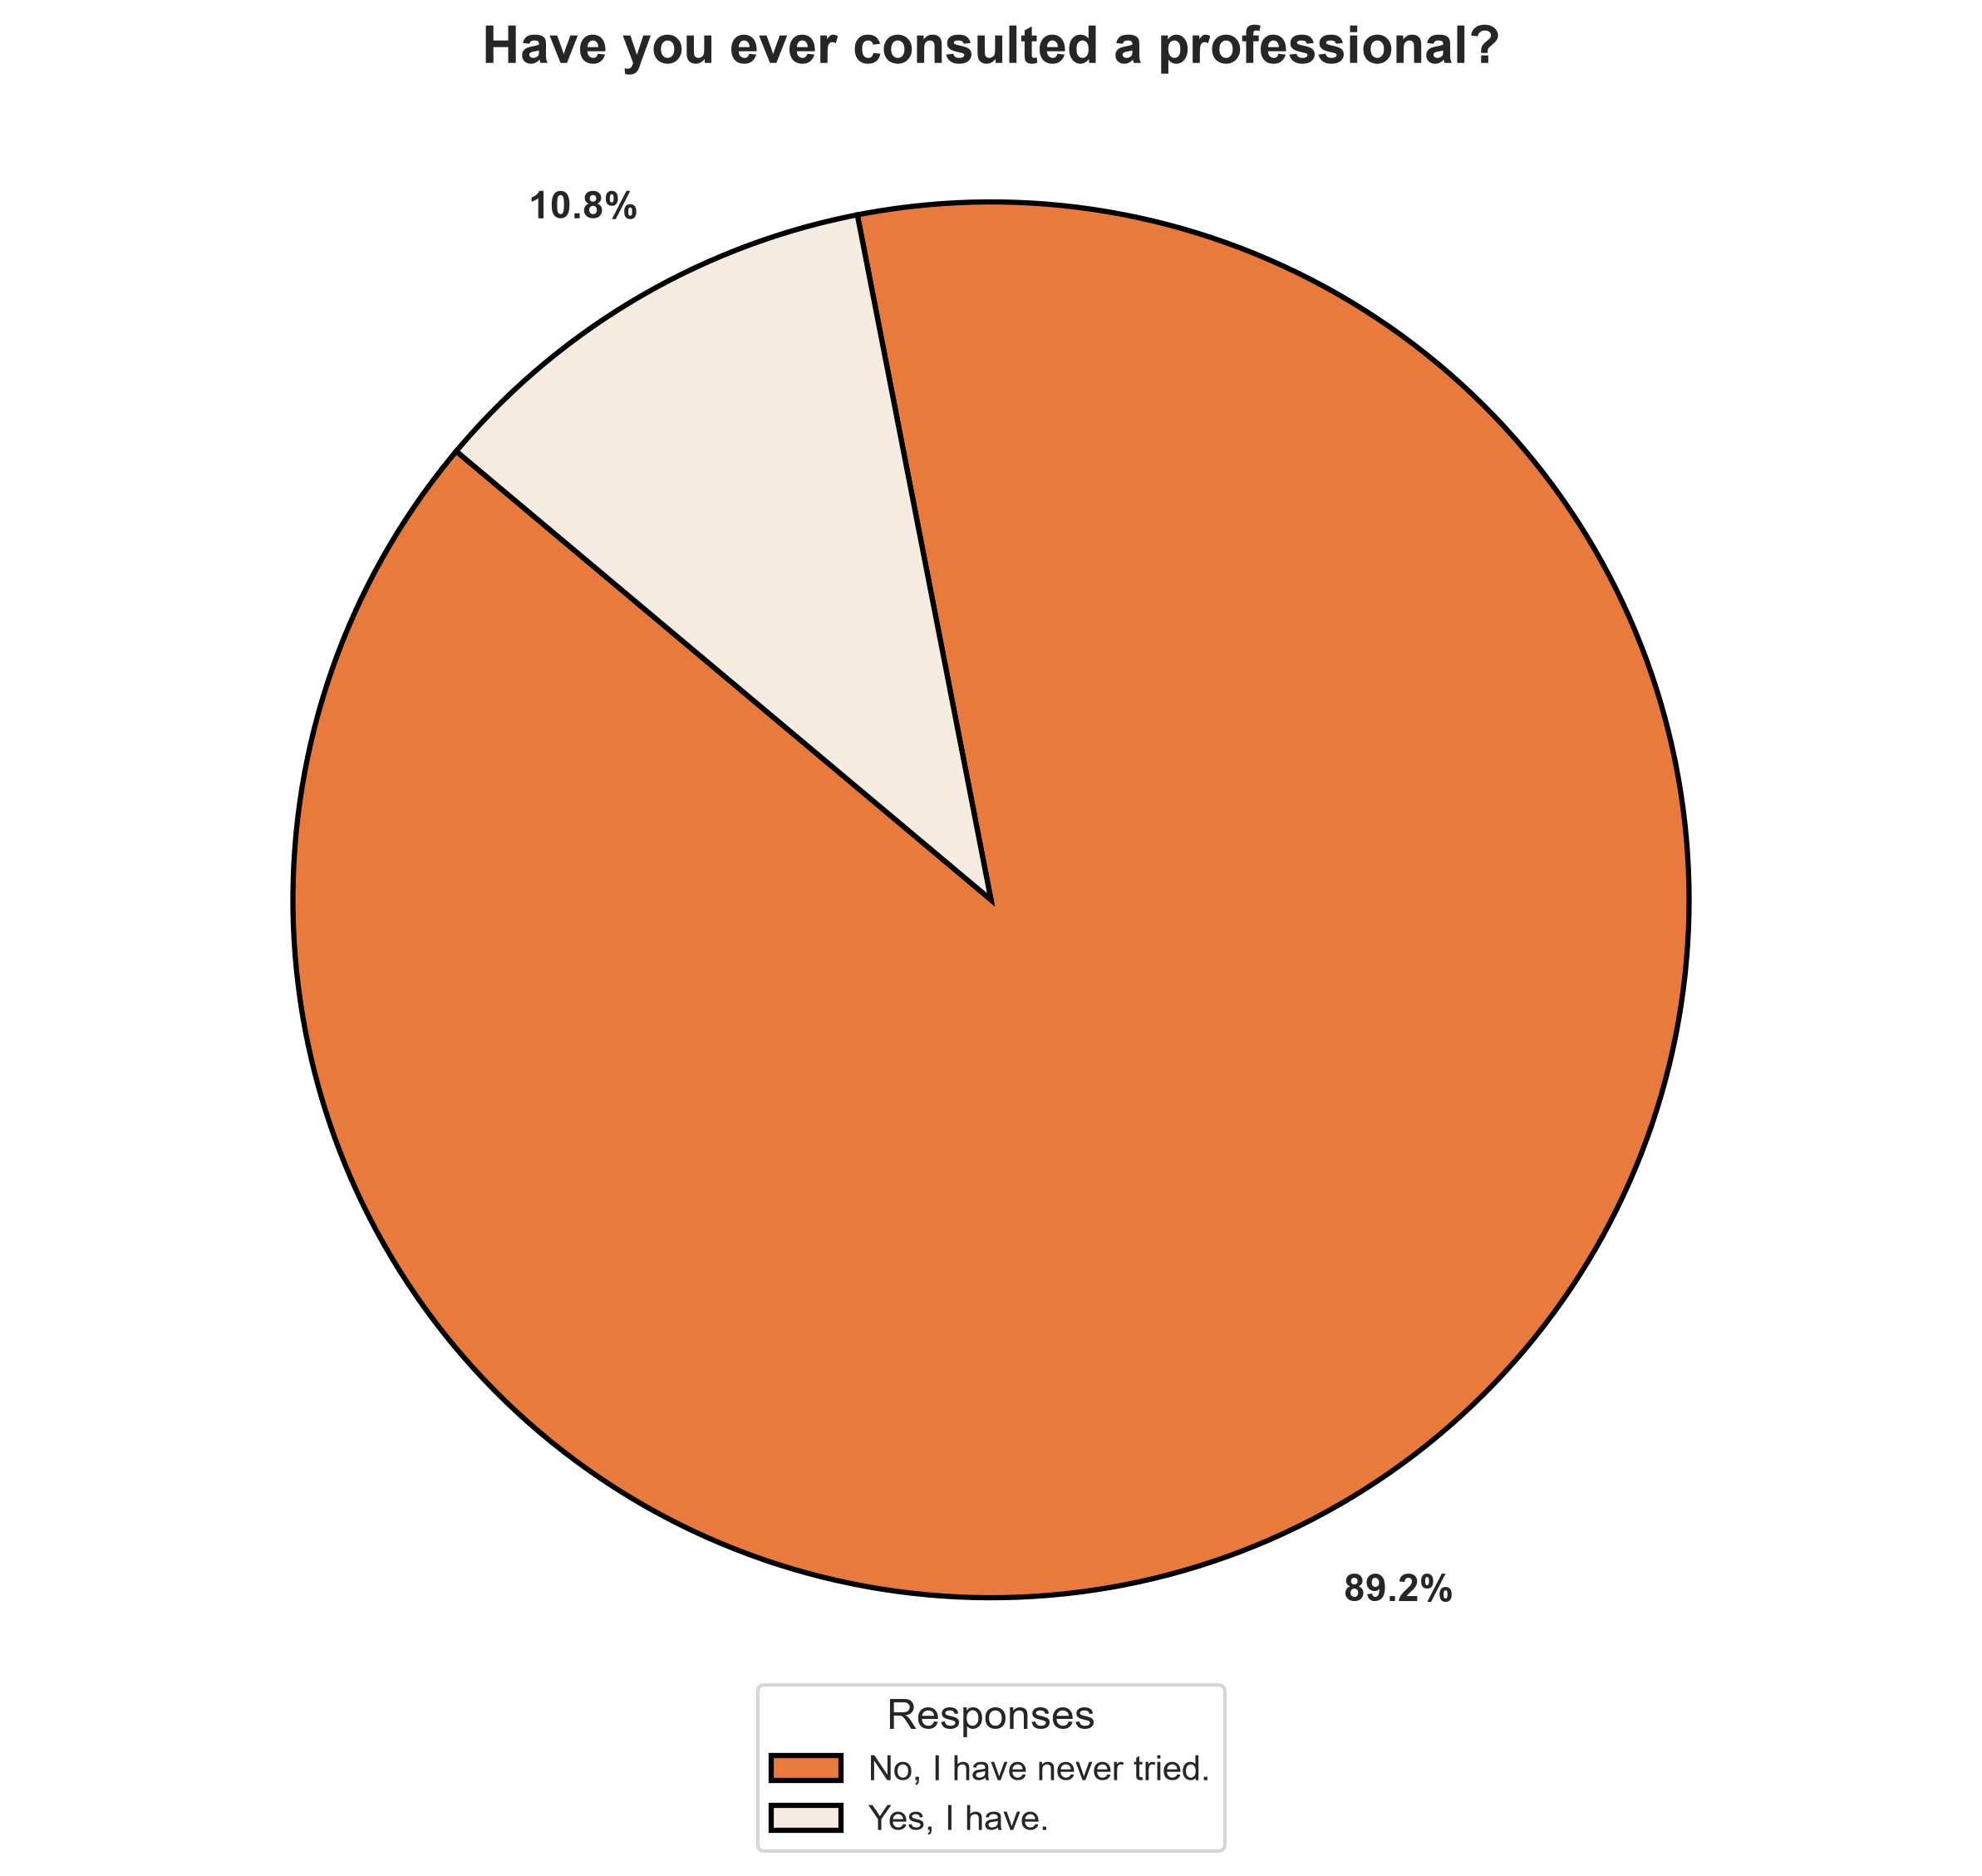

Success! The Pie Chart has been saved to: data_visualization\Attempted_to_Consult_Pie.png


In [33]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Turn on Seaborn styling for a clean background
sns.set_theme(style="white")

# 2. Load the dataset
cleaned_df = pd.read_csv("rawdata/Cleaned_Data.csv")

# 3. Grab Column 14 (Index 13)
attempt_col = cleaned_df.columns[13]

# 4. Count the answers
answer_counts = cleaned_df[attempt_col].dropna().value_counts()
labels = answer_counts.index
sizes = answer_counts.values

# 5. Set up the figure (Taller so the legend fits)
plt.figure(figsize=(10, 8), dpi=300)

# The EXTENDED Calico Theme Palette
extended_calico_colors = [
    "#E87A3E",  # Original Orange
    "#F5EBE1",  # Original Cream
    "#5C3A21",  # Original Brown
    "#E2A36B",  # Original Tan
    "#1D1D1B",  # Original Black
    "#A65D37",  # Rust Brown
    "#D9C3A9",  # Beige
    "#8C4F2B",  # Chocolate
    "#F2C48D",  # Golden Orange
    "#4A3525",  # Espresso
    "#CF8A5F",  # Muted Clay
    "#EBE2D5",  # Off-White
    "#2C1F16",  # Deep Charcoal
]

colors = [
    extended_calico_colors[i % len(extended_calico_colors)]
    for i in range(len(answer_counts))
]

# 6. Create the Pie Chart
wedges, texts, autotexts = plt.pie(
    sizes,
    colors=colors,
    autopct="%1.1f%%",
    startangle=140,
    pctdistance=1.15,  # Pushes percentages outside
    wedgeprops={"edgecolor": "black", "linewidth": 1.5},
    textprops={"fontsize": 11, "fontweight": "bold"},
)

# 7. Add title and styling
plt.title(
    "Have you ever consulted a professional?",
    fontsize=15,
    fontweight="bold",
    pad=20,
)

plt.axis("equal")

# 8. Add the Legend at the Bottom
plt.legend(
    wedges,
    labels,
    title="Responses",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.0),
    ncol=1,
    fontsize=10,
)

# 9. Save to the specific folder
save_folder = "data_visualization"
os.makedirs(save_folder, exist_ok=True)

file_path = os.path.join(save_folder, "Attempted_to_Consult_Pie.png")

plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Success! The Pie Chart has been saved to: {file_path}")

C:\Users\Nitro\AppData\Local\Temp\ipykernel_125648\3910020578.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


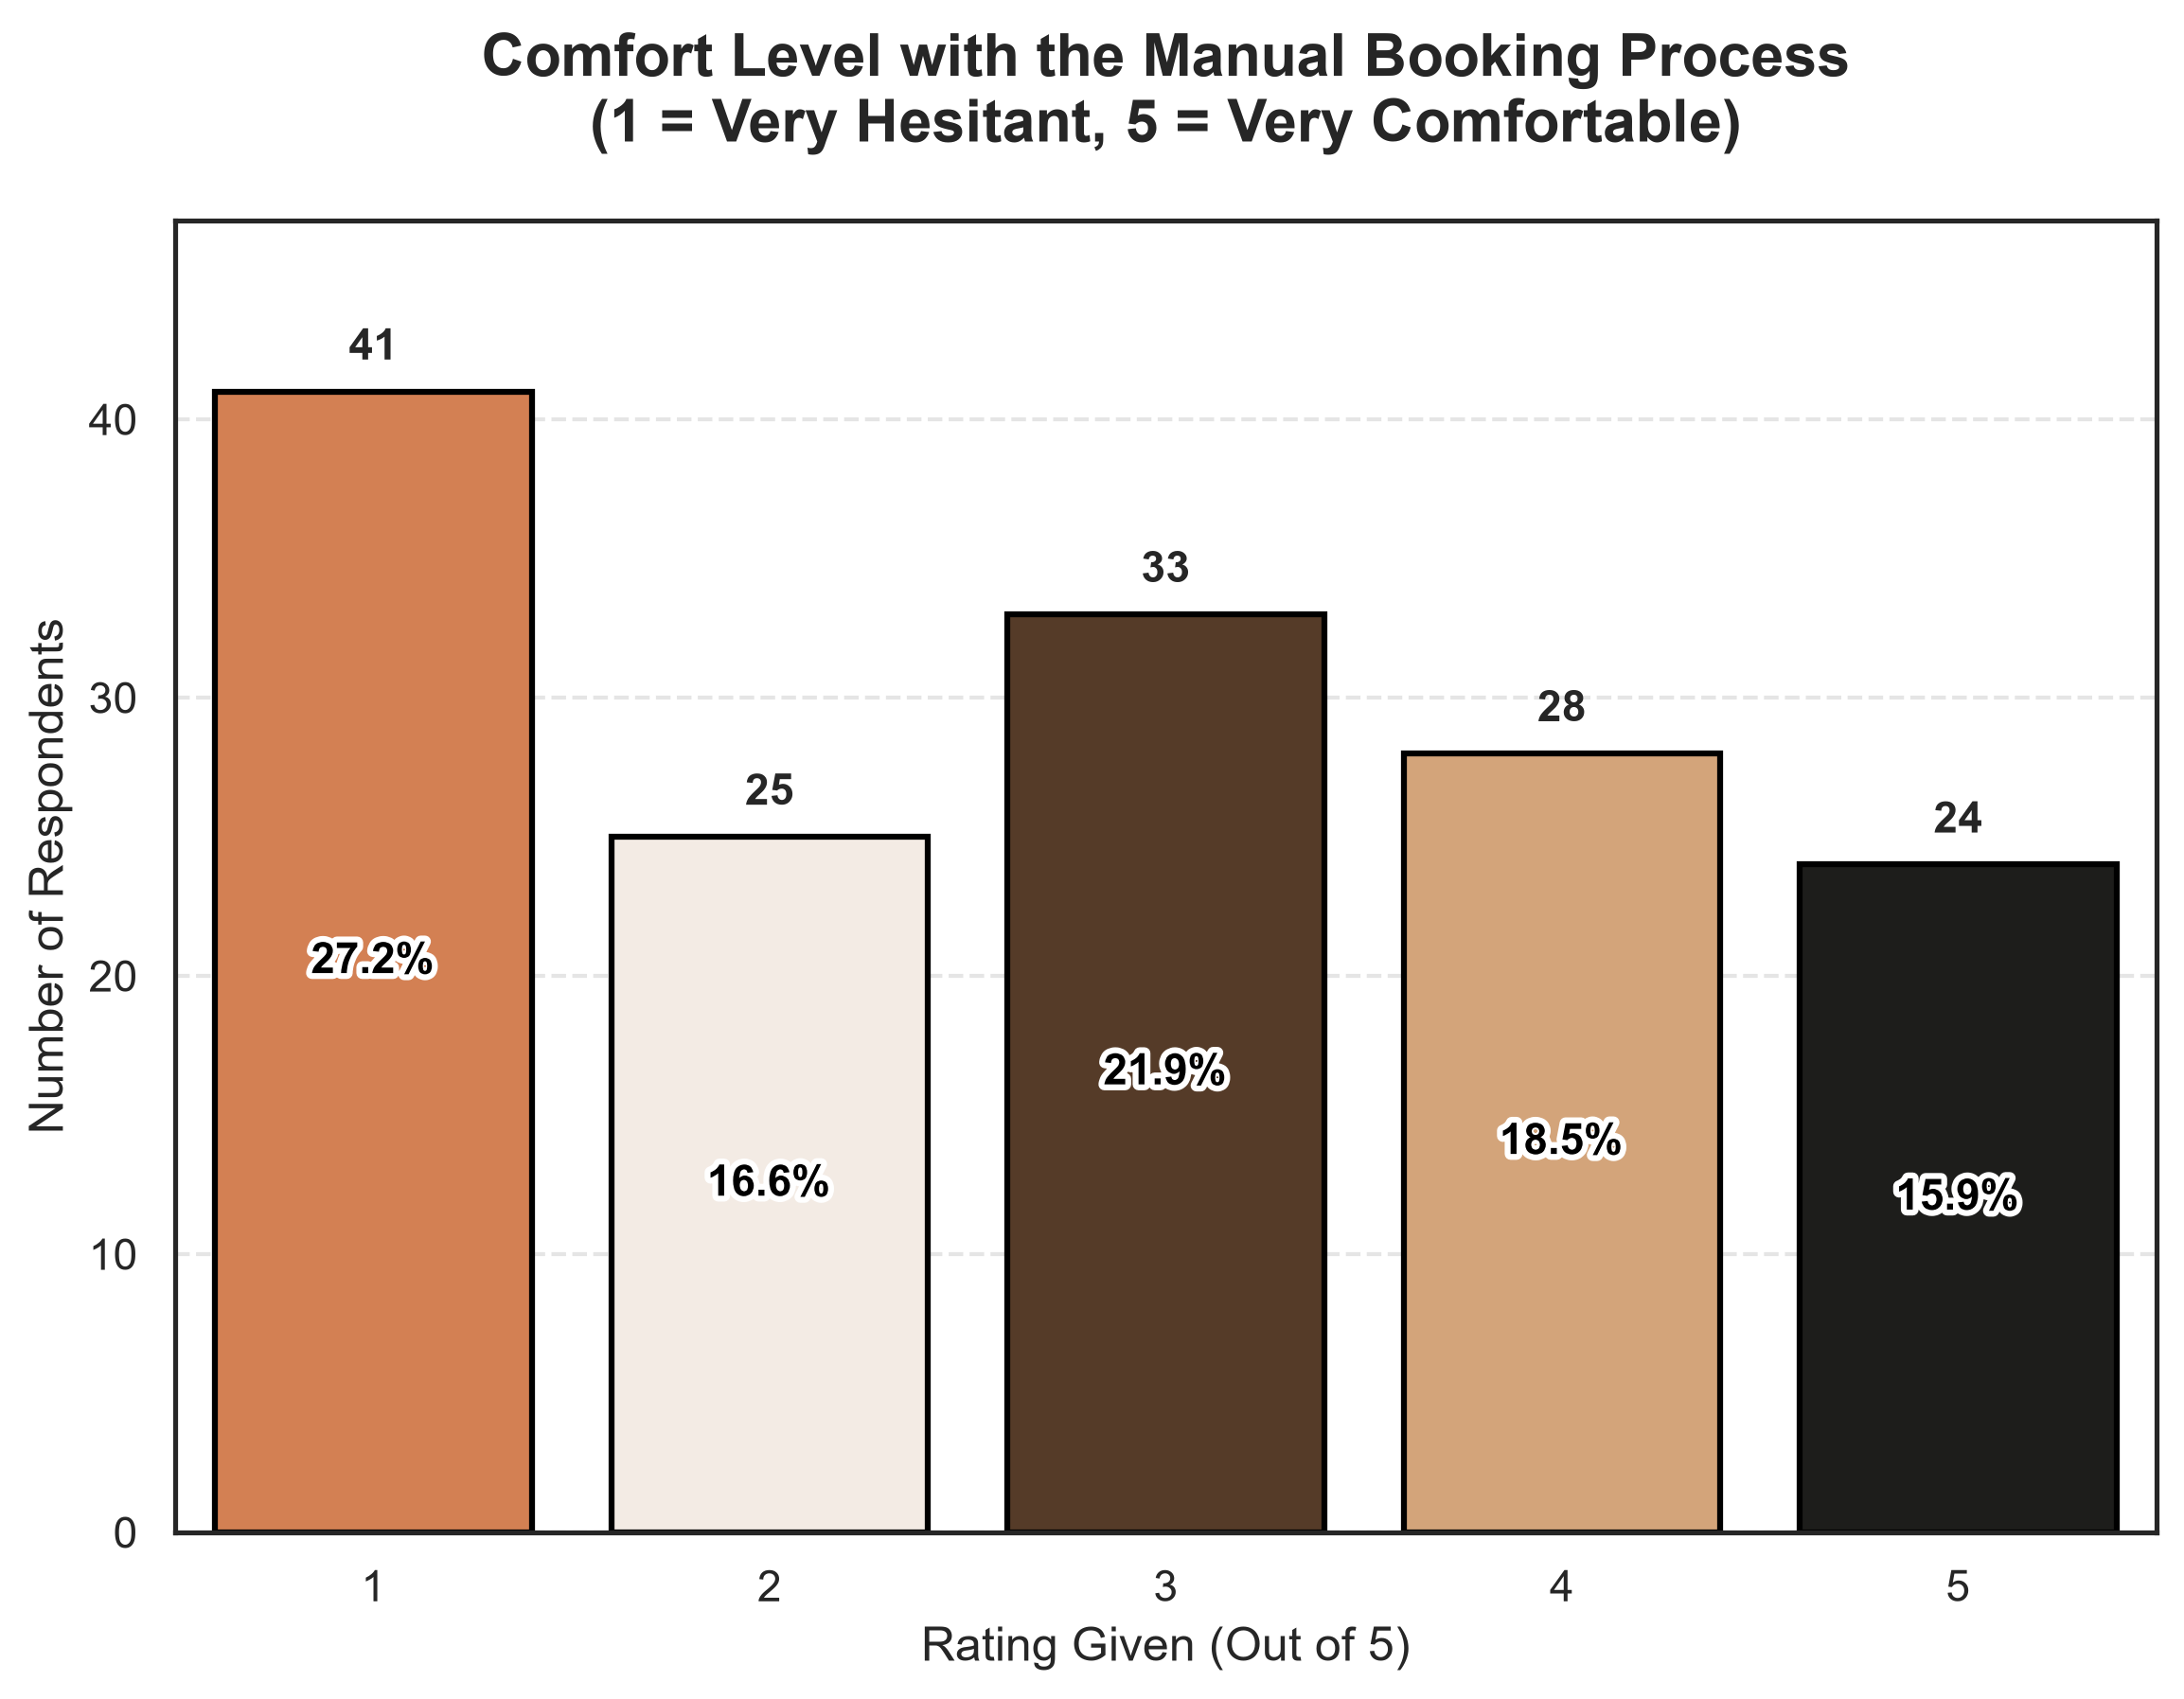

Success! The Vertical Bar Chart has been saved to: data_visualization\Consultation_Rating_Bar.png


In [37]:
import os
import matplotlib.patheffects as pe  # Used for text outlines
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Turn on Seaborn styling
sns.set_theme(style="white")

# 2. Load the dataset
cleaned_df = pd.read_csv("rawdata/Cleaned_Data.csv")

# 3. Grab Column 15 (Index 14)
rating_col = cleaned_df.columns[14]

# 4. CLEAN THE DATA
ratings = cleaned_df[rating_col].dropna().astype(int)
rating_counts = ratings.value_counts().sort_index().reset_index()
rating_counts.columns = ["Rating", "Count"]

# Calculate the TOTAL number of people for percentage calculations
total_responses = rating_counts["Count"].sum()

# 5. Set up the figure
plt.figure(figsize=(9, 6), dpi=300)

# The Calico Theme Palette
calico_colors = ["#E87A3E", "#F5EBE1", "#5C3A21", "#E2A36B", "#1D1D1B"]
colors = [calico_colors[i % len(calico_colors)] for i in range(len(rating_counts))]

# 6. Create a VERTICAL Bar Chart
ax = sns.barplot(
    data=rating_counts,
    x="Rating",
    y="Count",
    palette=colors,
    edgecolor="black",
    linewidth=1.5,
)

# Add 15% breathing room at the top
max_count = rating_counts["Count"].max()
plt.ylim(0, max_count * 1.15)

# 7. Add Numbers (Count on top, Percentage inside)
for patch in ax.patches:
    height = patch.get_height()
    if height > 0:
        # A) Put the exact COUNT on top of the bar
        plt.text(
            patch.get_x() + patch.get_width() / 2,
            height + (max_count * 0.02),
            str(int(height)),
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold",
        )

        # B) Put the PERCENTAGE inside the bar (only if bar is tall enough)
        if height > (max_count * 0.08):
            percentage = (height / total_responses) * 100
            plt.text(
                patch.get_x() + patch.get_width() / 2,
                height / 2,
                f"{percentage:.1f}%",
                ha="center",
                va="center",
                fontsize=11,
                fontweight="bold",
                color="black",
                path_effects=[pe.withStroke(linewidth=3, foreground="white")],
            )

# 8. Add title and styling
plt.title(
    "Comfort Level with the Manual Booking Process\n(1 = Very Hesitant, 5 = Very Comfortable)",
    fontsize=15,
    fontweight="bold",
    pad=20,
)
plt.xlabel("Rating Given (Out of 5)", fontsize=12)
plt.ylabel("Number of Respondents", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.5)

# 9. Save to the specific folder
save_folder = "data_visualization"
os.makedirs(save_folder, exist_ok=True)

file_path = os.path.join(save_folder, "Consultation_Rating_Bar.png")
plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Success! The Vertical Bar Chart has been saved to: {file_path}")

C:\Users\Nitro\AppData\Local\Temp\ipykernel_125648\1075201120.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


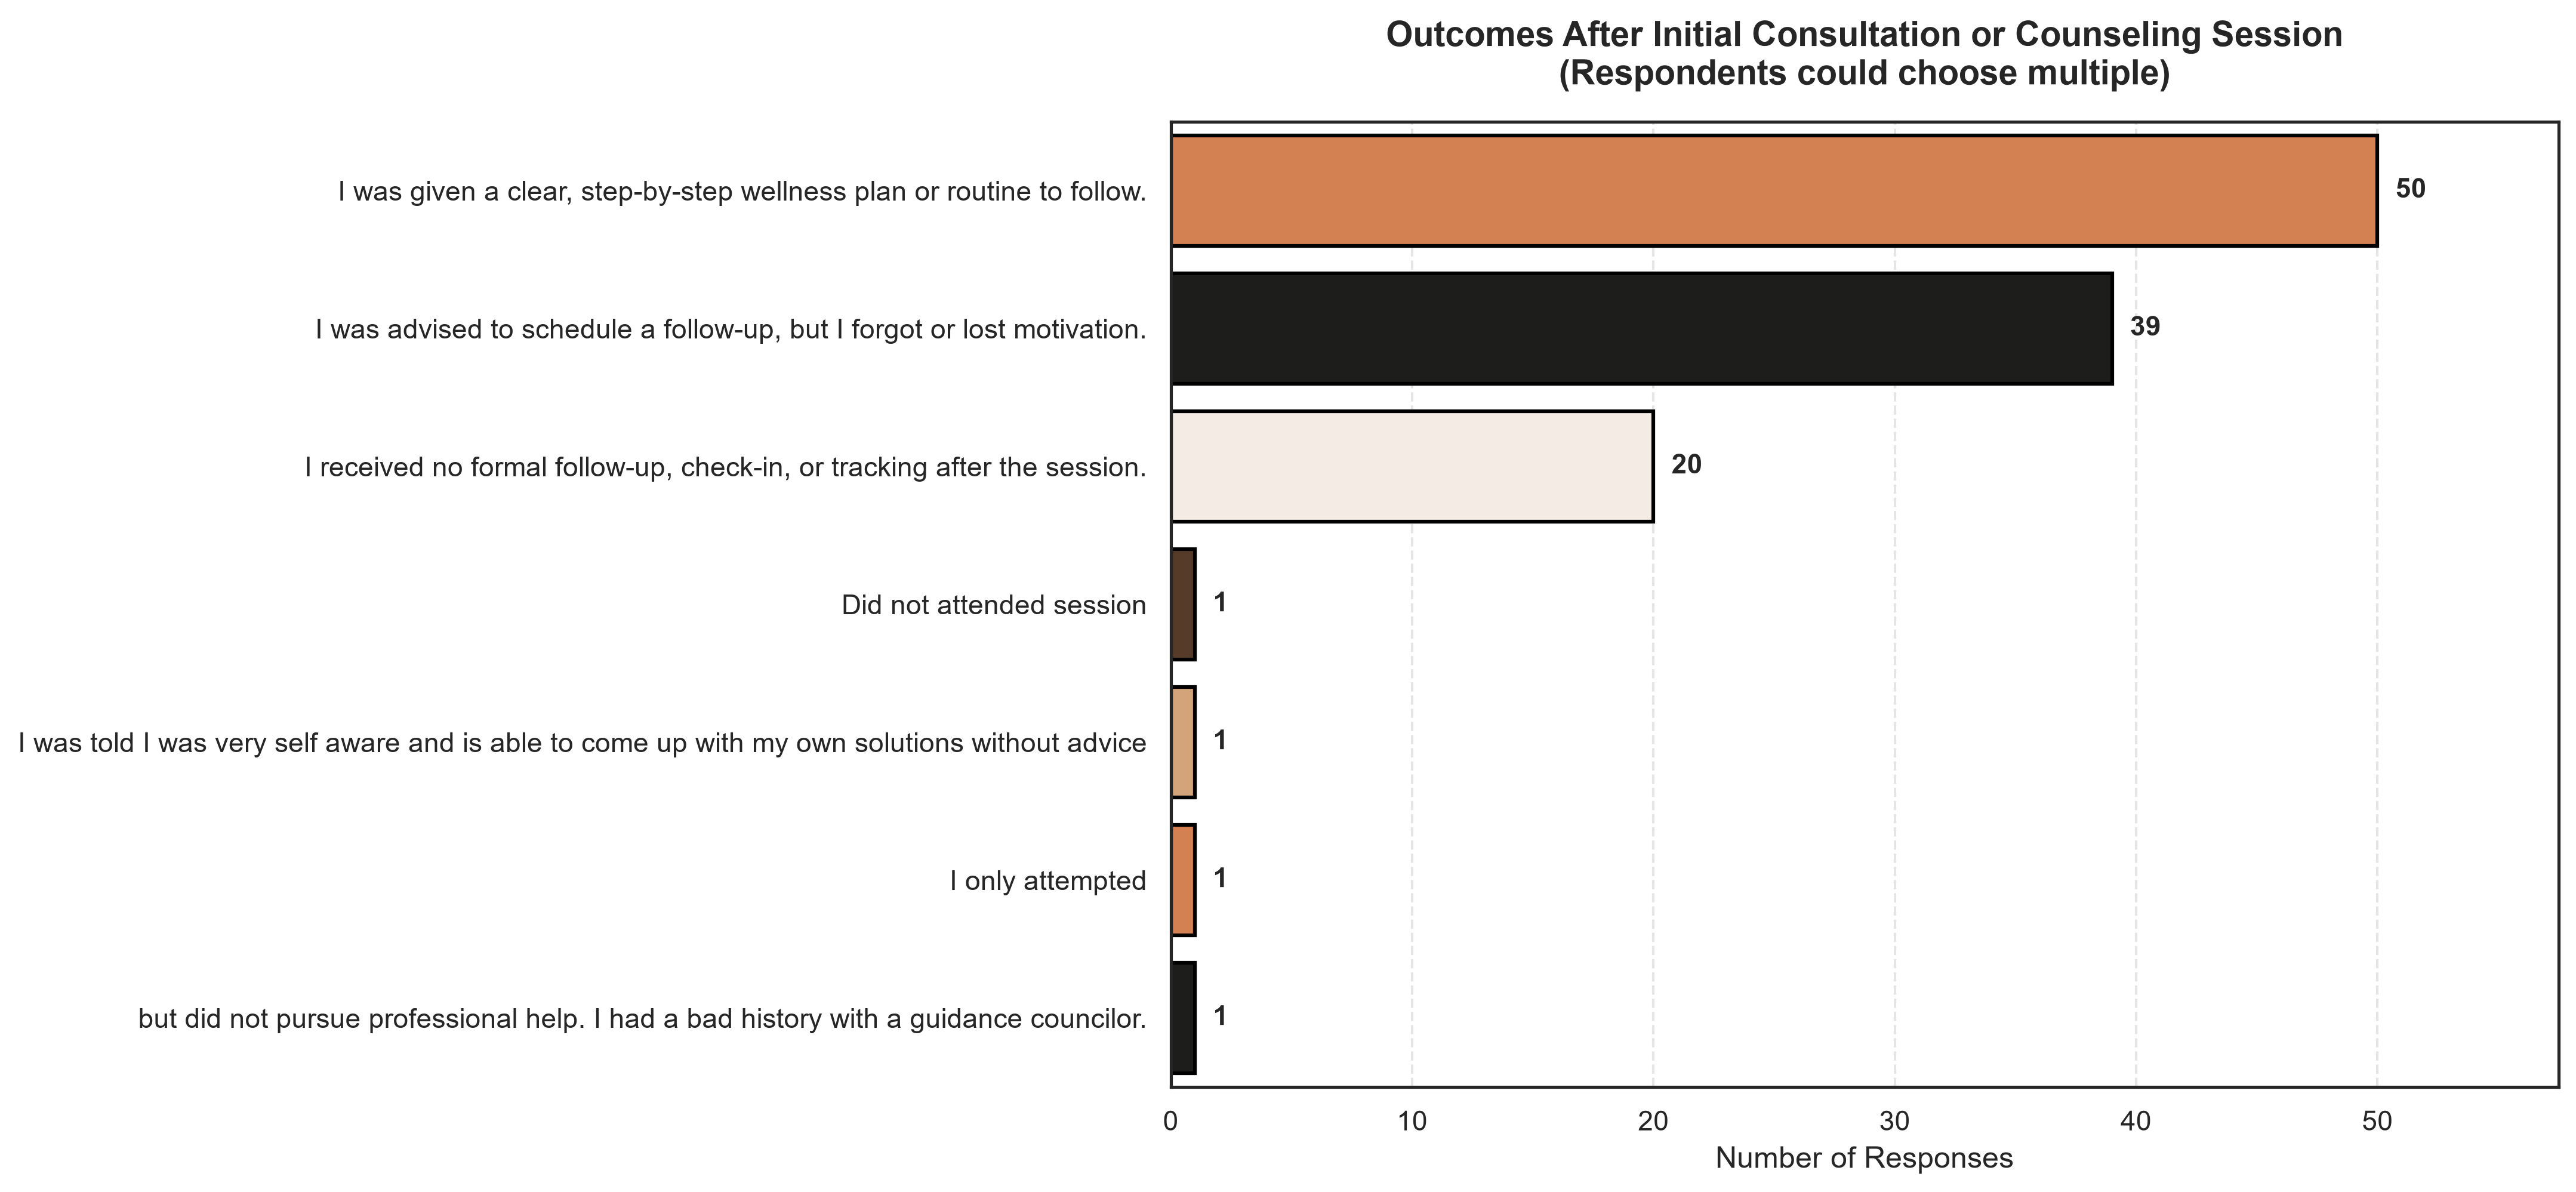

Success! The Outcomes chart has been saved to: data_visualization\Post_Consultation_Outcomes.png


In [50]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Turn on Seaborn styling
sns.set_theme(style="white")

# 2. Load the dataset
cleaned_df = pd.read_csv("rawdata/Cleaned_Data.csv")

# 3. Grab Column 16 (Index 15)
outcome_col = cleaned_df.columns[15]

# 4. SPLIT MULTIPLE ANSWERS
# We drop the blanks (people who said NO), split at commas, and separate them
separated_outcomes = (
    cleaned_df[outcome_col]
    .dropna()
    .astype(str)
    .str.split(";")
    .explode()
)

# Clean up accidental spaces and remove any completely empty strings
separated_outcomes = separated_outcomes.str.strip()
separated_outcomes = separated_outcomes[separated_outcomes != ""]

# 5. Count the answers
outcome_counts = separated_outcomes.value_counts().reset_index()
outcome_counts.columns = ["Outcome", "Count"]

# 6. Set up the figure
plt.figure(figsize=(10, 7), dpi=300)

# The Calico Theme Palette
calico_colors = ["#E87A3E", "#1D1D1B", "#F5EBE1", "#5C3A21", "#E2A36B"]
colors = [calico_colors[i % len(calico_colors)] for i in range(len(outcome_counts))]

# 7. Create the Horizontal Bar Chart
ax = sns.barplot(
    data=outcome_counts,
    x="Count",
    y="Outcome",
    palette=colors,
    edgecolor="black",
    linewidth=1.5,
)

# Give 15% breathing room on the right for the numbers
max_count = outcome_counts["Count"].max()
plt.xlim(0, max_count * 1.15)

# 8. Add the exact numbers to the right of the bars
for patch in ax.patches:
    width = patch.get_width()
    if width > 0:
        plt.text(
            width + (max_count * 0.015),
            patch.get_y() + patch.get_height() / 2,
            str(int(width)),
            ha="left",
            va="center",
            fontsize=11,
            fontweight="bold",
        )

# 9. Add title and styling
plt.title(
    "Outcomes After Initial Consultation or Counseling Session\n(Respondents could choose multiple)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Number of Responses", fontsize=12)
plt.ylabel("", fontsize=12)  # Hidden because the answers themselves are obvious

plt.yticks(fontsize=11)
plt.grid(axis="x", linestyle="--", alpha=0.5)

# 10. Save to the specific folder
save_folder = "data_visualization"
os.makedirs(save_folder, exist_ok=True)

file_path = os.path.join(save_folder, "Post_Consultation_Outcomes.png")
plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Success! The Outcomes chart has been saved to: {file_path}")

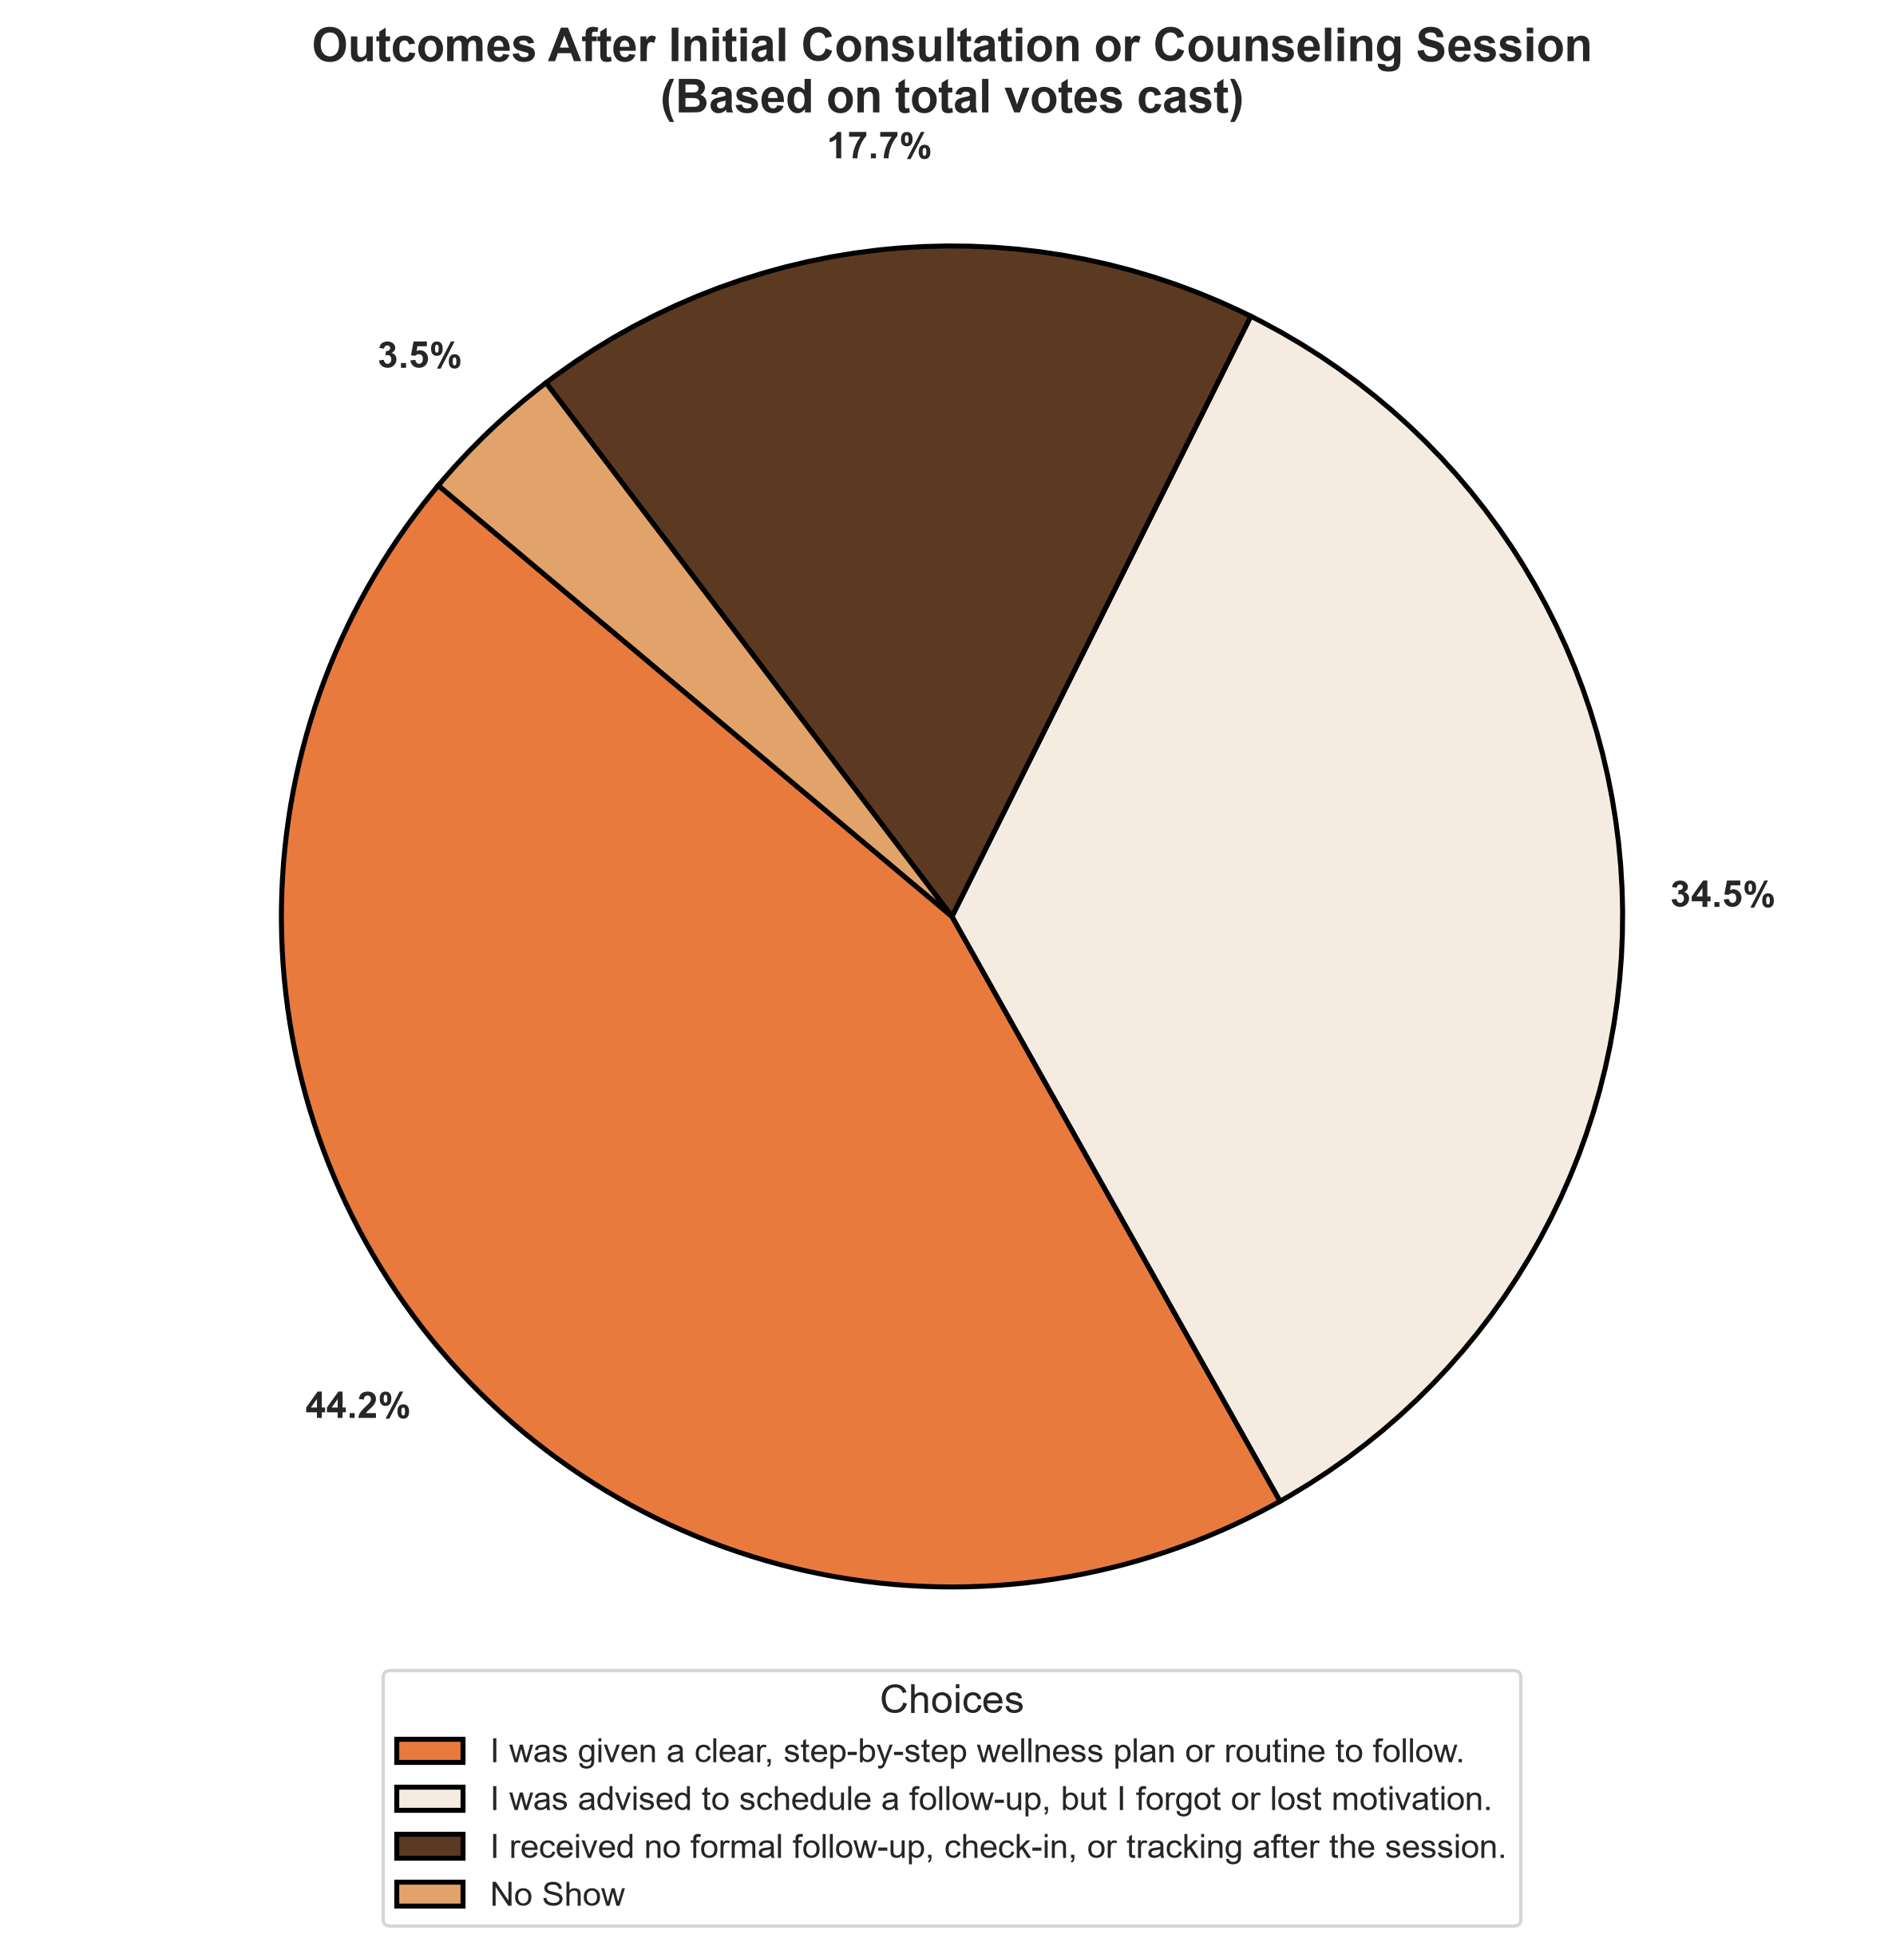

Success! The Pie Chart has been saved to: data_visualization\Post_Consultation_Outcomes_Pie.png


In [51]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Turn on Seaborn styling
sns.set_theme(style="white")

# 2. Load the dataset
cleaned_df = pd.read_csv("rawdata/Cleaned_Data.csv")

# 3. Grab Column 16 (Index 15)
outcome_col = cleaned_df.columns[15]

# 4. SPLIT MULTIPLE ANSWERS (By semi-colon)
separated_outcomes = (
    cleaned_df[outcome_col]
    .dropna()
    .astype(str)
    .str.split(";")
    .explode()
)

separated_outcomes = separated_outcomes.str.strip()
separated_outcomes = separated_outcomes[separated_outcomes != ""]

# --- HIDE SENSITIVE / CUSTOM TEXT ENTRIES ---
safe_choices = [
    "I was given a clear, step-by-step wellness plan or routine to follow.",
    "I was advised to schedule a follow-up, but I forgot or lost motivation.",
    "I received no formal follow-up, check-in, or tracking after the session.",
]

# The list of answers you want to group as "No Show"
no_show_entries = [
    "Did not attended session",
    "I was told I was very self aware and is able to come up with my own solutions without advice",
    "I only attempted",
    "but did not pursue professional help. I had a bad history with a guidance councilor.",
]

# Our custom sorting rule
def categorize_outcome(answer):
    if answer in safe_choices:
        return answer
    elif answer in no_show_entries:
        return "No Show"
    else:
        return "Other"

# Apply the custom rule!
separated_outcomes = separated_outcomes.apply(categorize_outcome)

# 5. Count the answers
outcome_counts = separated_outcomes.value_counts()
labels = outcome_counts.index
sizes = outcome_counts.values

# 6. Set up the figure
plt.figure(figsize=(10, 8), dpi=300)

# The Calico Theme Palette
extended_calico_colors = [
    "#E87A3E", "#F5EBE1", "#5C3A21", "#E2A36B", "#1D1D1B",
    "#A65D37", "#D9C3A9", "#8C4F2B",
]

colors = [
    extended_calico_colors[i % len(extended_calico_colors)]
    for i in range(len(outcome_counts))
]

# 7. Create the Pie Chart
wedges, texts, autotexts = plt.pie(
    sizes,
    colors=colors,
    autopct="%1.1f%%",
    startangle=140,
    pctdistance=1.15,
    wedgeprops={"edgecolor": "black", "linewidth": 1.5},
    textprops={"fontsize": 11, "fontweight": "bold"},
)

# 8. Add title and styling
plt.title(
    "Outcomes After Initial Consultation or Counseling Session\n(Based on total votes cast)",
    fontsize=14,
    fontweight="bold",
    pad=20,
)

plt.axis("equal")

# 9. Add the Legend at the Bottom
plt.legend(
    wedges,
    labels,
    title="Choices",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.0),
    ncol=1,
    fontsize=10,
)

# 10. Save to the specific folder
save_folder = "data_visualization"
os.makedirs(save_folder, exist_ok=True)

file_path = os.path.join(save_folder, "Post_Consultation_Outcomes_Pie.png")
plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Success! The Pie Chart has been saved to: {file_path}")

C:\Users\Nitro\AppData\Local\Temp\ipykernel_125648\2572284697.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


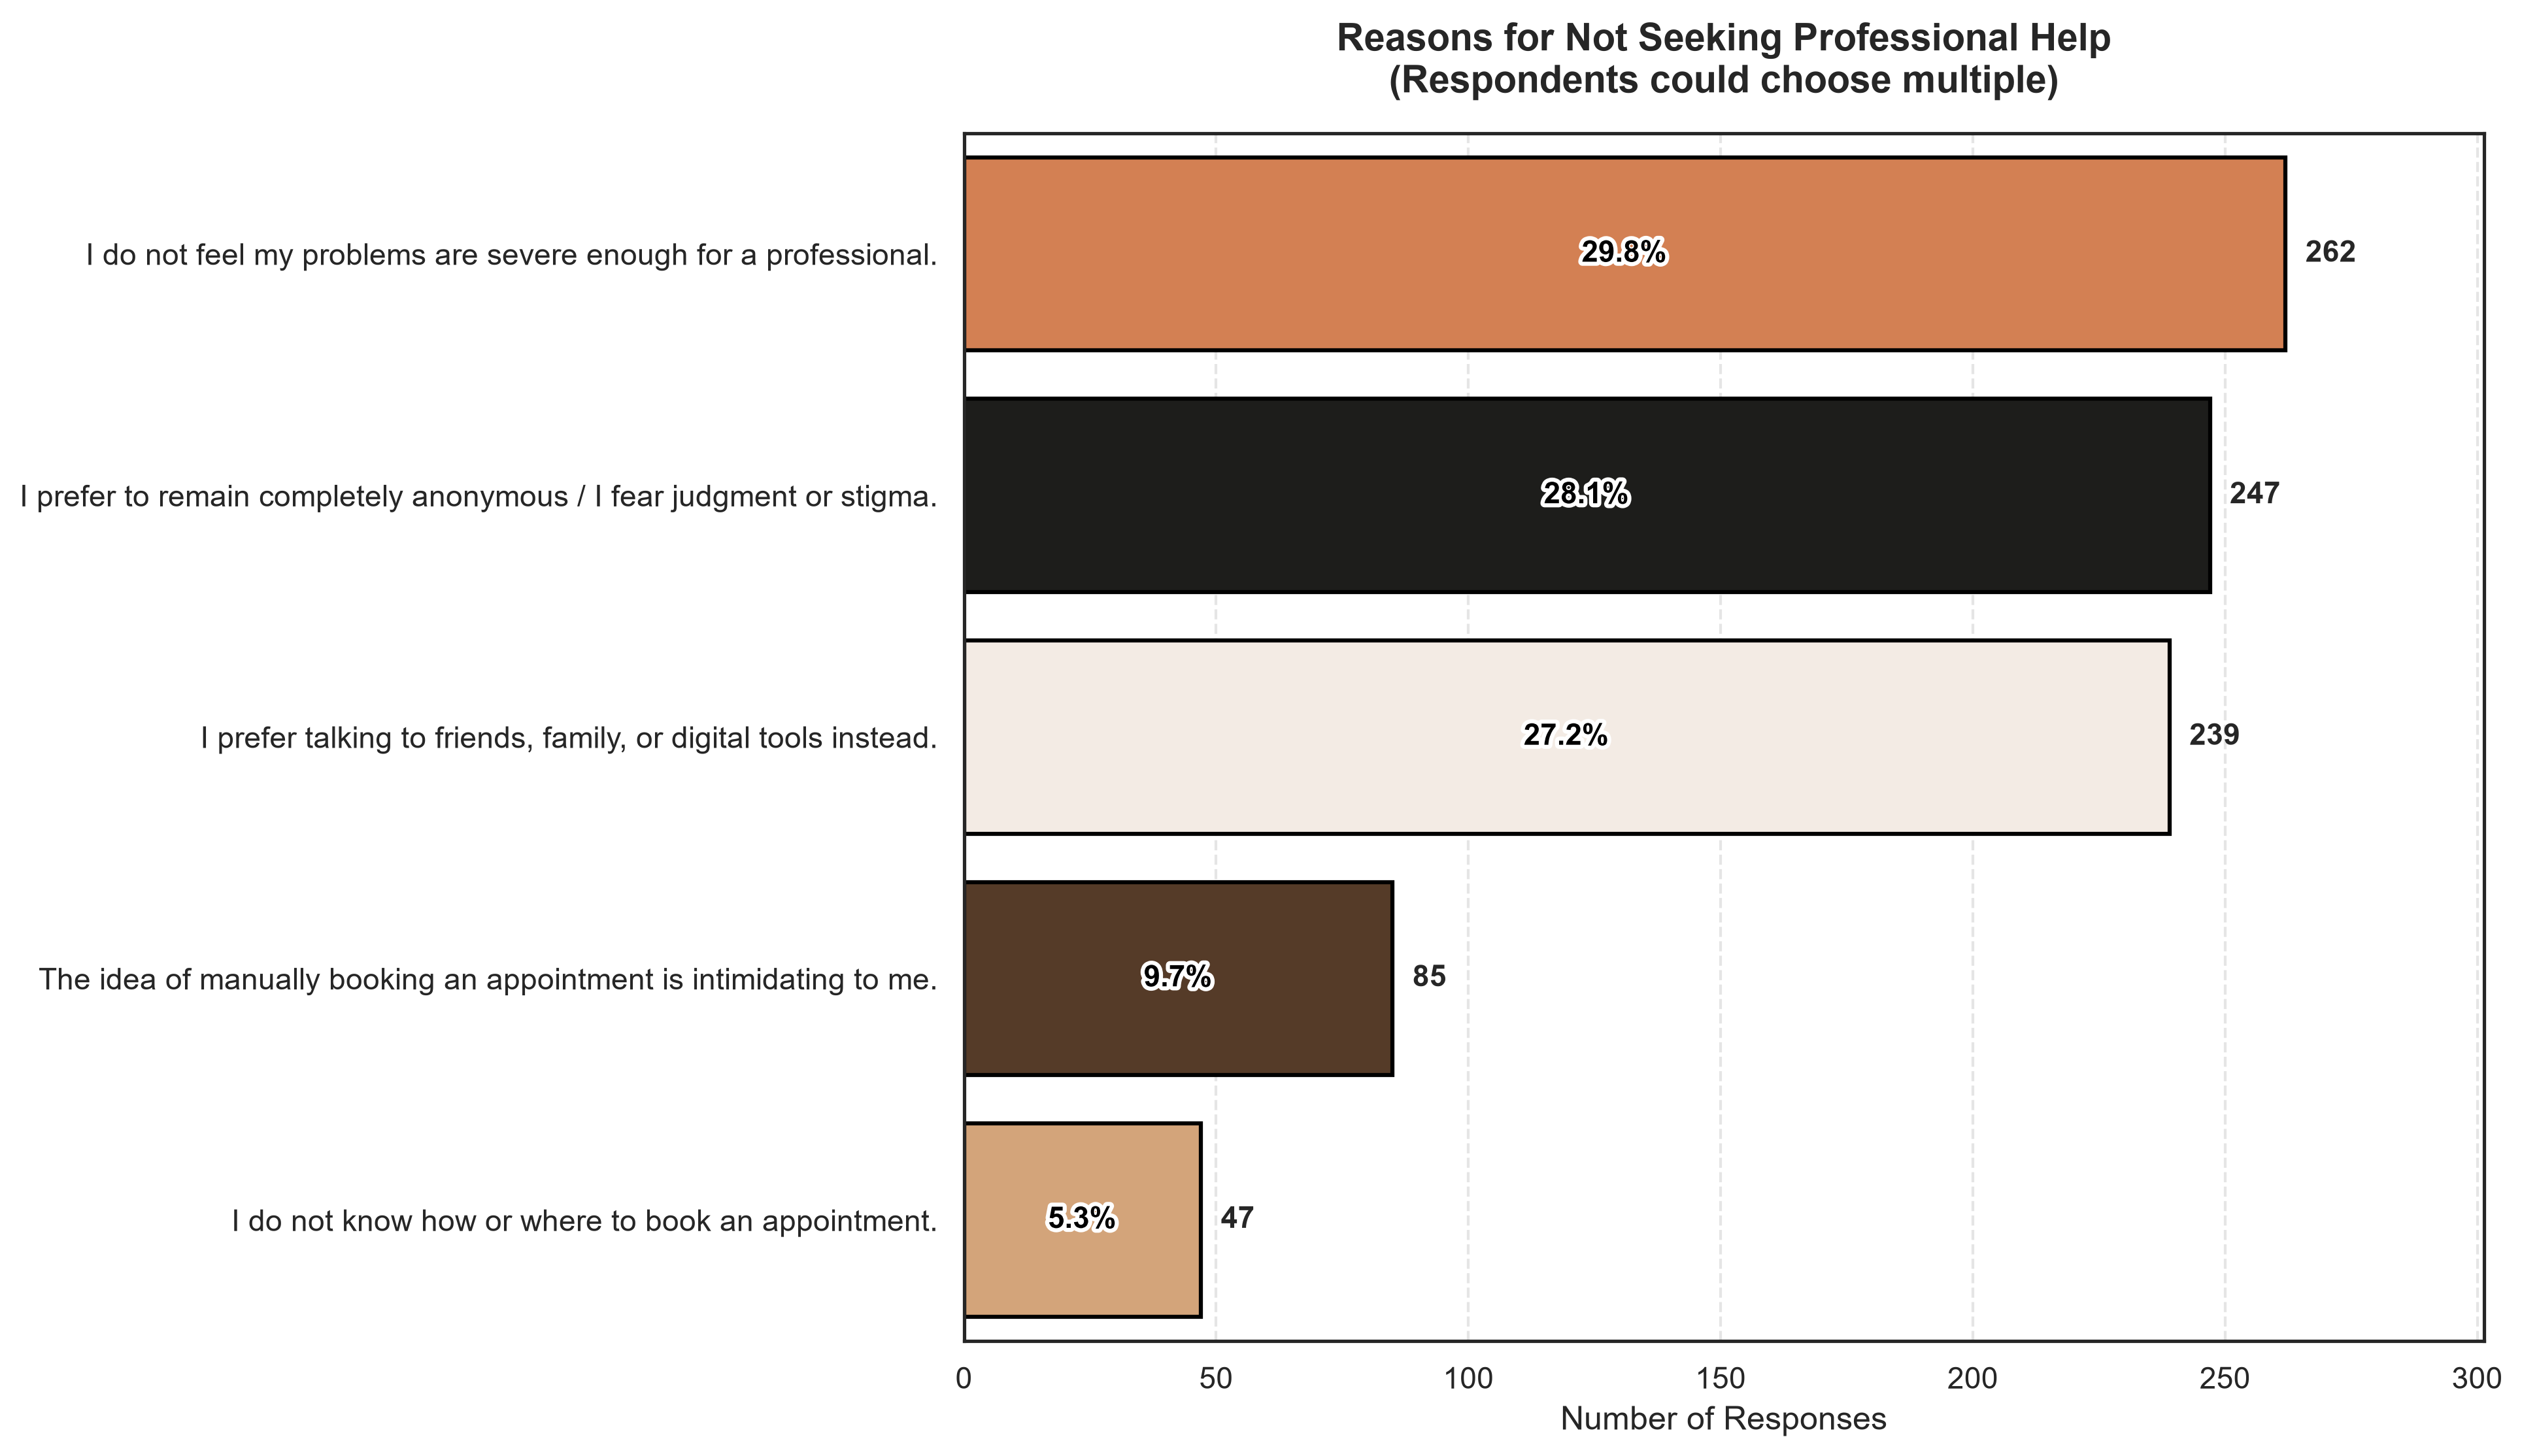

Success! The Reasons chart has been saved to: data_visualization\Reasons_For_NO_Bar.png


In [59]:
import os
import matplotlib.patheffects as pe  # Used for the white text outlines!
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Turn on Seaborn styling
sns.set_theme(style="white")

# 2. Load the dataset
cleaned_df = pd.read_csv("rawdata/Cleaned_Data.csv")

# 3. Grab Column 17 (Index 16)
reason_col = cleaned_df.columns[16]

# 4. SPLIT MULTIPLE ANSWERS
separated_reasons = (
    cleaned_df[reason_col]
    .dropna()
    .astype(str)
    .str.split(";")
    .explode()
)

# Clean up accidental spaces
separated_reasons = separated_reasons.str.strip()
separated_reasons = separated_reasons[separated_reasons != ""]

# 5. Count the answers
reason_counts = separated_reasons.value_counts().reset_index()
reason_counts.columns = ["Reason", "Count"]

# Calculate the TOTAL number of votes for percentages
total_votes = reason_counts["Count"].sum()

# 6. Set up the figure (Taller to comfortably fit long sentences)
plt.figure(figsize=(10, 8), dpi=300)

# The Calico Theme Palette
extended_calico_colors = [
    "#E87A3E", "#1D1D1B", "#F5EBE1", "#5C3A21", "#E2A36B",
    "#A65D37", "#D9C3A9", "#8C4F2B",
]

colors = [
    extended_calico_colors[i % len(extended_calico_colors)]
    for i in range(len(reason_counts))
]

# 7. Create the Horizontal Bar Chart
ax = sns.barplot(
    data=reason_counts,
    x="Count",
    y="Reason",
    palette=colors,
    edgecolor="black",
    linewidth=1.5,
)

# Give 15% breathing room on the right for the numbers
max_count = reason_counts["Count"].max()
plt.xlim(0, max_count * 1.15)

# 8. Add the Exact Numbers and Percentages!
for patch in ax.patches:
    width = patch.get_width()
    if width > 0:
        # A) Put the COUNT to the right of the bar
        plt.text(
            width + (max_count * 0.015),
            patch.get_y() + patch.get_height() / 2,
            str(int(width)),
            ha="left",
            va="center",
            fontsize=11,
            fontweight="bold",
        )

        # B) Put the PERCENTAGE INSIDE the bar (if wide enough)
        if width > (max_count * 0.08):
            percentage = (width / total_votes) * 100
            plt.text(
                width / 2,
                patch.get_y() + patch.get_height() / 2,
                f"{percentage:.1f}%",
                ha="center",
                va="center",
                fontsize=11,
                fontweight="bold",
                color="black",
                path_effects=[pe.withStroke(linewidth=3, foreground="white")],
            )

# 9. Add title and styling
plt.title(
    "Reasons for Not Seeking Professional Help\n(Respondents could choose multiple)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Number of Responses", fontsize=12)
plt.ylabel("", fontsize=12)

plt.yticks(fontsize=11)
plt.grid(axis="x", linestyle="--", alpha=0.5)

# 10. Save to the specific folder
save_folder = "data_visualization"
os.makedirs(save_folder, exist_ok=True)

file_path = os.path.join(save_folder, "Reasons_For_NO_Bar.png")
plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Success! The Reasons chart has been saved to: {file_path}")

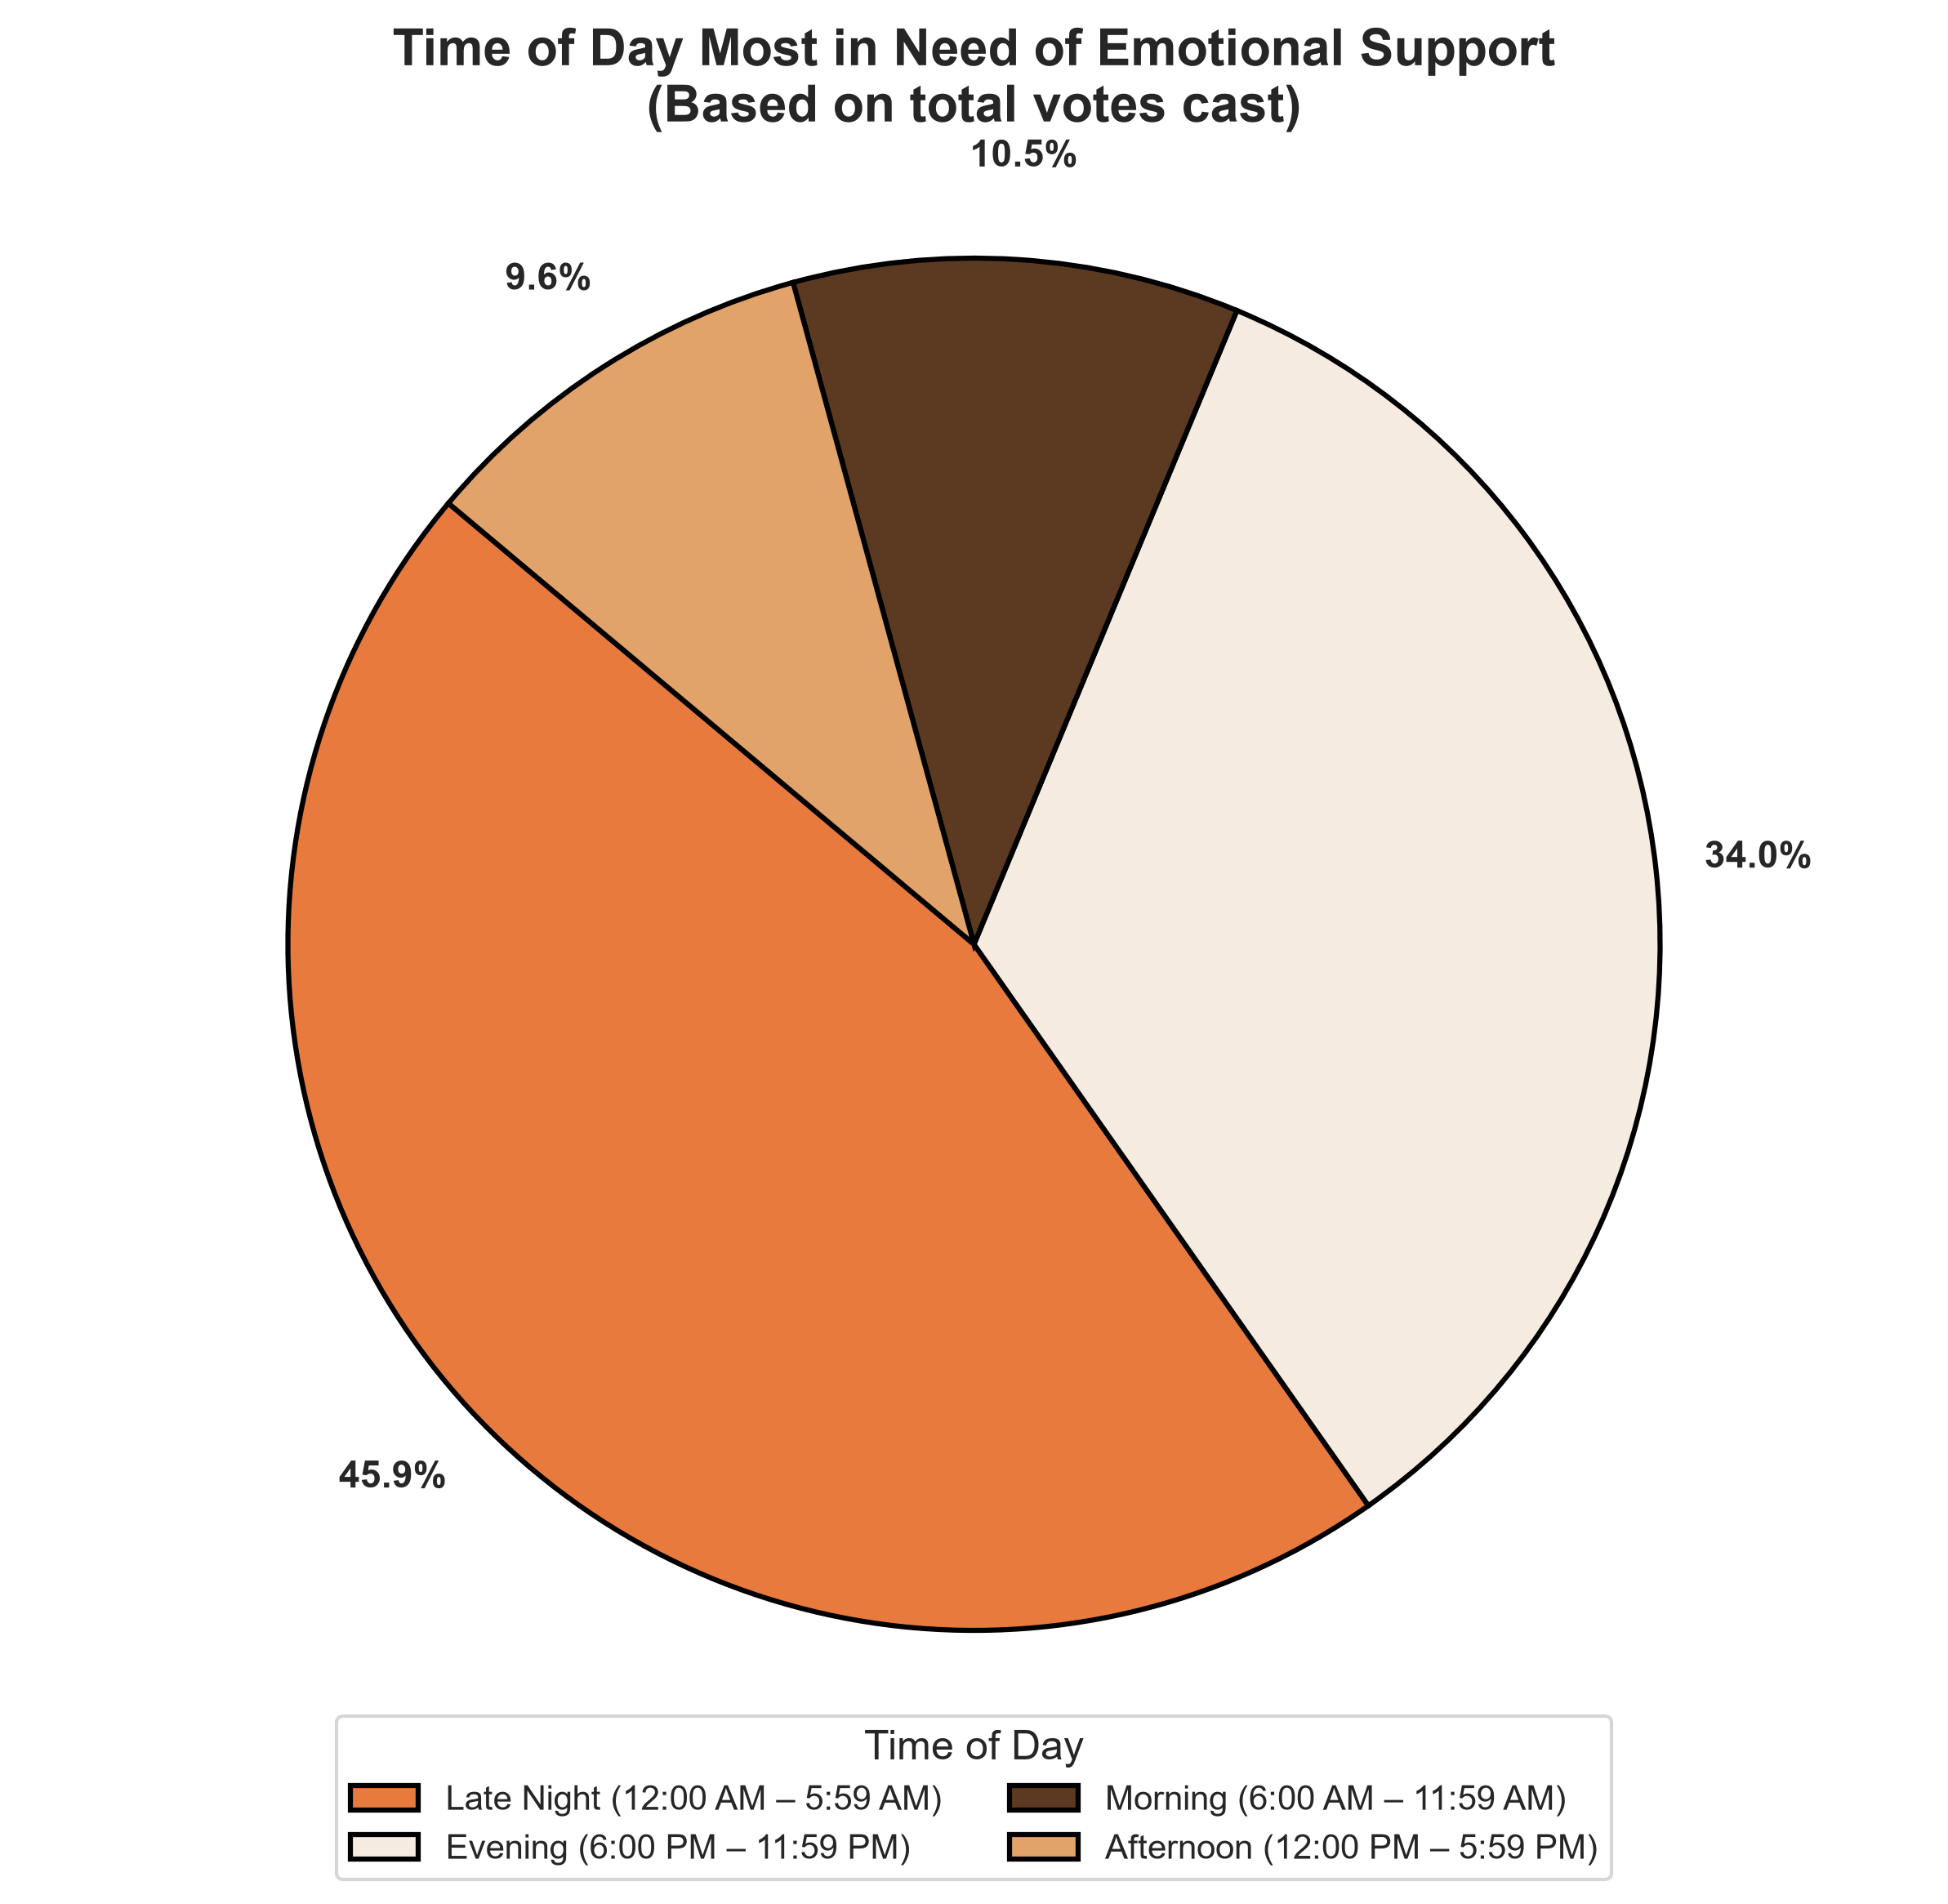

Success! The Pie Chart has been saved to: data_visualization\Overwhelmed_Time_Pie.png


In [60]:
import os
import matplotlib.patheffects as pe  # Used for the white text outlines!
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Turn on Seaborn styling for a clean background
sns.set_theme(style="white")

# 2. Load the dataset
cleaned_df = pd.read_csv("rawdata/Cleaned_Data.csv")

# 3. Grab Column 18 (Index 17)
time_col = cleaned_df.columns[17]

# 4. SPLIT THE MULTIPLE ANSWERS
separated_times = (
    cleaned_df[time_col]
    .dropna()
    .astype(str)
    .str.split(",")
    .explode()
)

# Clean up accidental spaces
separated_times = separated_times.str.strip()
separated_times = separated_times[separated_times != ""]

# 5. Count the answers
answer_counts = separated_times.value_counts()
labels = answer_counts.index
sizes = answer_counts.values

# 6. Set up the figure (Taller so the legend fits)
plt.figure(figsize=(10, 8), dpi=300)

# The EXTENDED Calico Theme Palette (so colors don't repeat)
extended_calico_colors = [
    "#E87A3E", "#F5EBE1", "#5C3A21", "#E2A36B", "#1D1D1B",
    "#A65D37", "#D9C3A9", "#8C4F2B", "#F2C48D", "#4A3525",
    "#CF8A5F", "#EBE2D5", "#2C1F16",
]

colors = [
    extended_calico_colors[i % len(extended_calico_colors)]
    for i in range(len(answer_counts))
]

# 7. Create the Pie Chart
wedges, texts, autotexts = plt.pie(
    sizes,
    colors=colors,
    autopct="%1.1f%%",
    startangle=140,
    pctdistance=1.15,  # Pushes percentages to the outside!
    wedgeprops={"edgecolor": "black", "linewidth": 1.5},
    textprops={"fontsize": 11, "fontweight": "bold"},
)

# 8. Add title and styling
plt.title(
    "Time of Day Most in Need of Emotional Support\n(Based on total votes cast)",
    fontsize=15,
    fontweight="bold",
    pad=20,
)

plt.axis("equal")

# 9. Add the Legend at the Bottom
plt.legend(
    wedges,
    labels,
    title="Time of Day",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.0),  # Pushes it below the chart
    ncol=2,                     # Split into 2 columns so it looks neat
    fontsize=10,
)

# 10. Save to the specific folder
save_folder = "data_visualization"
os.makedirs(save_folder, exist_ok=True)

file_path = os.path.join(save_folder, "Overwhelmed_Time_Pie.png")
plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Success! The Pie Chart has been saved to: {file_path}")

C:\Users\Nitro\AppData\Local\Temp\ipykernel_125648\4092310699.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


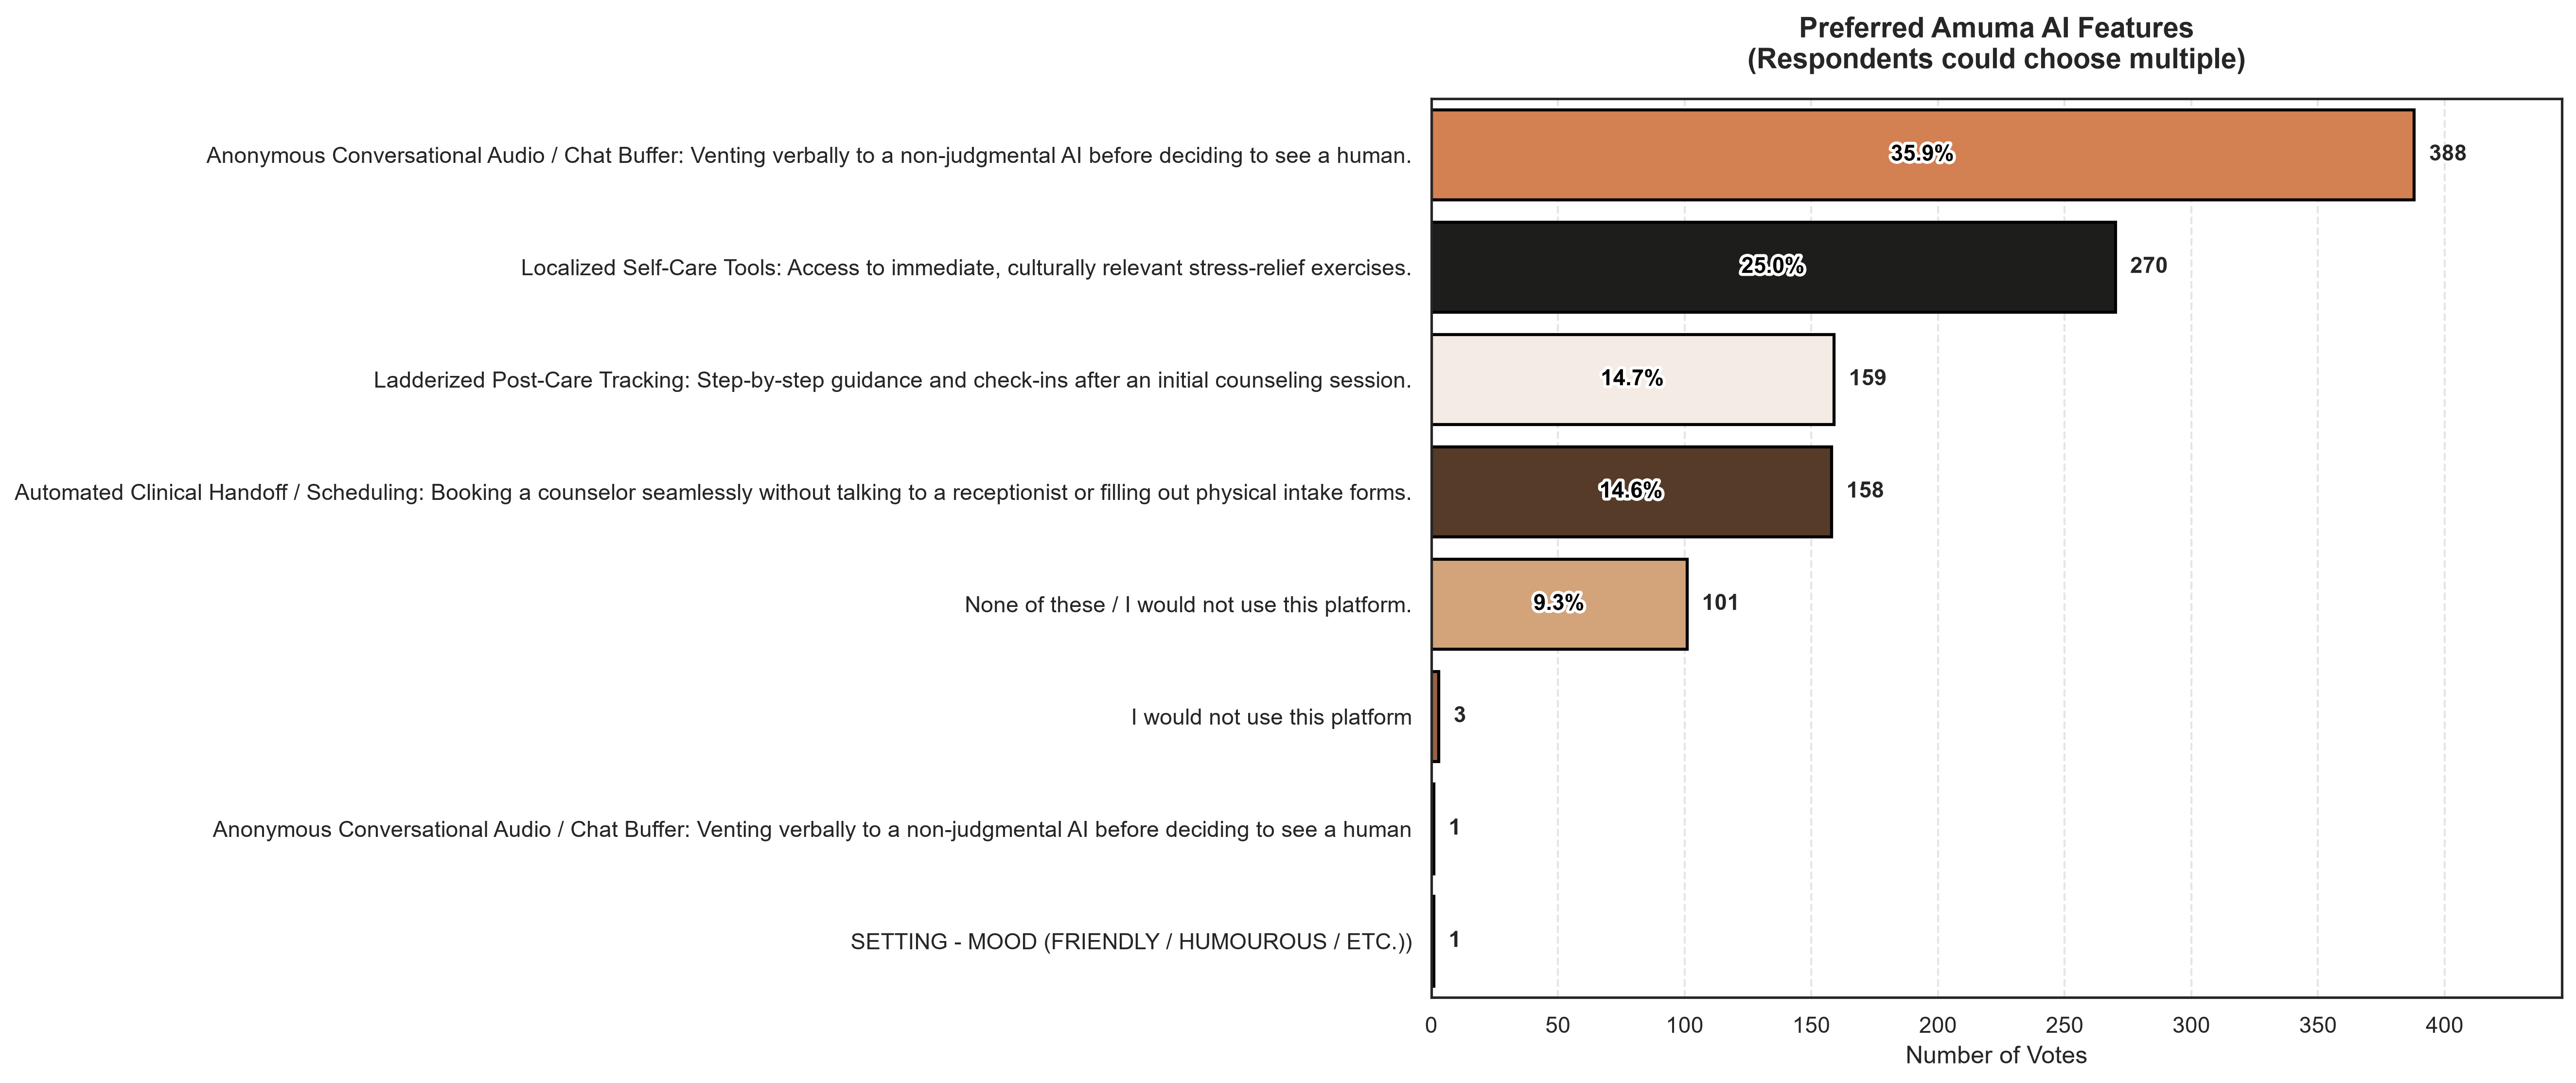

Success! The Features chart has been saved to: data_visualization\Amuma_AI_Features_Bar.png


In [62]:
import os
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Turn on Seaborn styling
sns.set_theme(style="white")

# 2. Load the dataset
cleaned_df = pd.read_csv("rawdata/Cleaned_Data.csv")

# 3. Grab Column 19 (Index 18)
feature_col = cleaned_df.columns[18]

# 4. SPLIT MULTIPLE ANSWERS
# (Assuming comma-separated; switch to ";" if normalized with semicolons during cleaning)
separated_features = (
    cleaned_df[feature_col]
    .dropna()
    .astype(str)
    .str.split(";")
    .explode()
)

# Clean up accidental spaces and remove empty entries
separated_features = separated_features.str.strip()
separated_features = separated_features[separated_features != ""]

# 5. Count the answers
feature_counts = separated_features.value_counts().reset_index()
feature_counts.columns = ["Feature", "Count"]

# Calculate the TOTAL number of votes for percentages
total_votes = feature_counts["Count"].sum()

# 6. Set up the figure (Taller to comfortably fit all options)
plt.figure(figsize=(10, 8), dpi=300)

# The Extended Calico Theme Palette
extended_calico_colors = [
    "#E87A3E", "#1D1D1B", "#F5EBE1", "#5C3A21", "#E2A36B",
    "#A65D37", "#D9C3A9", "#8C4F2B",
]

colors = [
    extended_calico_colors[i % len(extended_calico_colors)]
    for i in range(len(feature_counts))
]

# 7. Create the Horizontal Bar Chart
ax = sns.barplot(
    data=feature_counts,
    x="Count",
    y="Feature",
    palette=colors,
    edgecolor="black",
    linewidth=1.5,
)

# Give 15% breathing room on the right for the numbers
max_count = feature_counts["Count"].max()
plt.xlim(0, max_count * 1.15)

# 8. Add the Exact Numbers and Percentages
for patch in ax.patches:
    width = patch.get_width()
    if width > 0:
        # A) Put the COUNT to the right of the bar
        plt.text(
            width + (max_count * 0.015),
            patch.get_y() + patch.get_height() / 2,
            str(int(width)),
            ha="left",
            va="center",
            fontsize=11,
            fontweight="bold",
        )

        # B) Put the PERCENTAGE INSIDE the bar (if wide enough)
        if width > (max_count * 0.08):
            percentage = (width / total_votes) * 100
            plt.text(
                width / 2,
                patch.get_y() + patch.get_height() / 2,
                f"{percentage:.1f}%",
                ha="center",
                va="center",
                fontsize=11,
                fontweight="bold",
                color="black",
                path_effects=[pe.withStroke(linewidth=3, foreground="white")],
            )

# 9. Add title and styling
plt.title(
    "Preferred Amuma AI Features\n(Respondents could choose multiple)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Number of Votes", fontsize=12)
plt.ylabel("", fontsize=12)

plt.yticks(fontsize=11)
plt.grid(axis="x", linestyle="--", alpha=0.5)

# 10. Save to the specific folder
save_folder = "data_visualization"
os.makedirs(save_folder, exist_ok=True)

file_path = os.path.join(save_folder, "Amuma_AI_Features_Bar.png")
plt.savefig(file_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Success! The Features chart has been saved to: {file_path}")